# ***SCIN Dataset Overview***

## **What is SCIN?**

**SCIN (Skin Condition Image Network)** is a publicly released dermatology dataset containing:
- User-submitted skin condition images
- Self-reported demographic and symptom information
- Expert dermatologist labels
- Multiple skin tone annotations (Fitzpatrick and Monk scales)

The dataset was designed to support research in:
- Skin disease classification
- Fairness and bias analysis across skin tones
- Multimodal learning (images + tabular data)
- Clinical AI benchmarking
<br>

---

<br>

## **Dataset Structure**

SCIN consists of two main CSV files:

### `scin_cases.csv`
Contains:
- Case-level metadata (`case_id`, release info, year)
- Demographics (age group, sex at birth, skin type)
- Race/ethnicity (binary columns)
- Skin texture and body part information
- Reported symptoms
- Condition duration
- User-selected related category
- Up to 3 image paths and shot types

This file primarily represents **user-reported information and image references**.

---

### `scin_labels.csv`
Contains:
- Dermatologist gradability assessments
- Dermatologist condition labels (with confidence scores)
- Aggregated weighted condition label (normalized probabilities)
- Dermatologist-estimated Fitzpatrick skin type
- Monk skin tone labels (India and US graders)

This file represents **expert annotations and diagnostic signals**.

<br>

---

<br>

# ***Our Goal***

Our goal is to build a multi-model fusion where:
- Model-1: A classification model built on tabular data of the dataset
- Model-2: A CNN model built on images <br>
are combined to create a final model which classifies the skin condition.

# ***Features of the SCIN Dataset:***


## **Dataset 1:** `scin_cases.csv`

### *Identifiers*
- `case_id`
- `source`
- `release`
- `year`

---

### *Demographics*
- `age_group`
- `sex_at_birth`
- `fitzpatrick_skin_type`

---

### *Race / Ethnicity (Binary Columns)*
- `race_ethnicity_AMERICAN_INDIAN_OR_ALASKA_NATIVE`
- `race_ethnicity_ASIAN`
- `race_ethnicity_BLACK_OR_AFRICAN_AMERICAN`
- `race_ethnicity_HISPANIC_LATINO_OR_SPANISH_ORIGIN`
- `race_ethnicity_MIDDLE_EASTERN_OR_NORTH_AFRICAN`
- `race_ethnicity_NATIVE_HAWAIIAN_OR_PACIFIC_ISLANDER`
- `race_ethnicity_WHITE`
- `race_ethnicity_OTHER_RACE`
- `race_ethnicity_PREFER_NOT_TO_ANSWER`
- `race_ethnicity_TWO_OR_MORE_AFTER_MITIGATION`

---

### *Texture (Binary Columns)*
- `textures_TEXTURE_UNSPECIFIED`
- `textures_RAISED_OR_BUMPY`
- `textures_FLAT`
- `textures_ROUGH_OR_FLAKY`
- `textures_FLUID_FILLED`

---

### *Body Parts (Binary Columns)*
- `body_parts_HEAD_OR_NECK`
- `body_parts_ARM`
- `body_parts_PALM`
- `body_parts_BACK_OF_HAND`
- `body_parts_TORSO_FRONT`
- `body_parts_TORSO_BACK`
- `body_parts_GENITALIA_OR_GROIN`
- `body_parts_BUTTOCKS`
- `body_parts_LEG`
- `body_parts_FOOT_TOP_OR_SIDE`
- `body_parts_FOOT_SOLE`
- `body_parts_OTHER`

---

### *Condition Symptoms (Binary Columns)*
- `condition_symptoms_BOTHERSOME_APPEARANCE`
- `condition_symptoms_BLEEDING`
- `condition_symptoms_INCREASING_SIZE`
- `condition_symptoms_DARKENING`
- `condition_symptoms_ITCHING`
- `condition_symptoms_BURNING`
- `condition_symptoms_PAIN`
- `condition_symptoms_NO_RELEVANT_EXPERIENCE`

---

### *Other Symptoms (Binary Columns)*
- `other_symptoms_FEVER`
- `other_symptoms_CHILLS`
- `other_symptoms_FATIGUE`
- `other_symptoms_JOINT_PAIN`
- `other_symptoms_MOUTH_SORES`
- `other_symptoms_SHORTNESS_OF_BREATH`
- `other_symptoms_NO_RELEVANT_SYMPTOMS`

---

### *Case Details*
- `related_category`
- `condition_duration`

---

### *Image Information*
- `image_1_path`
- `image_1_shot_type`
- `image_2_path`
- `image_2_shot_type`
- `image_3_path`
- `image_3_shot_type`


---

## **Dataset 2:** `scin_labels.csv`

### *Identifier*
- `case_id`

---

### *Skin Condition Gradability*
- `dermatologist_gradable_for_skin_condition_1`
- `dermatologist_gradable_for_skin_condition_2`
- `dermatologist_gradable_for_skin_condition_3`

---

### *Dermatologist Condition Labels*
- `dermatologist_skin_condition_label_name`
- `dermatologist_skin_condition_confidence`
- `weighted_skin_condition_label`

---

### *Fitzpatrick (Dermatologist Estimated)*
- `dermatologist_gradable_for_fitzpatrick_skin_type_1`
- `dermatologist_fitzpatrick_skin_type_label_1`
- `dermatologist_gradable_for_fitzpatrick_skin_type_2`
- `dermatologist_fitzpatrick_skin_type_label_2`
- `dermatologist_gradable_for_fitzpatrick_skin_type_3`
- `dermatologist_fitzpatrick_skin_type_label_3`

---

### *Monk Skin Tone Labels*
- `gradable_for_monk_skin_tone_india`
- `monk_skin_tone_label_india`
- `gradable_for_monk_skin_tone_us`
- `monk_skin_tone_label_us`

# ***Phases of the Project***

## **Phase-1: Extracting and formatting data**
- In this phase we will extract the data from both the datasets.
- We will join the datasets based on `case_id`.
- We will also extract the images with the respective `case_id`

## **Phase-2: Data Exploration**
- In this phase we will find out missing feature values and instances with no label.
- We will also choose the instances which are reliable based on `dermatologist_skin_condition_confidence` socres.
- We will see the class label distribution of the data.
- We will also see the distribution of images from various body parts.

## **Phase-3: Classification Model**
- We will build a classification model using the tabular data.
- We will experiment with machine learning models and FNNs and choose the best model.

## **Phase-4: CNN Model**
- We will run multiple modelling experiments on the images and choose the best CNN.

## **Phase-5: Model Fusion**
- We will try to combine both the models by sending the individual model outputs to a meta learner.
- We will also extract features from both models and build a multi-model.
- We will choose the best performing model as our final model.

# ***Phase-1: Extracting and formatting data***
- In this phase we will extract the data from both the datasets.
- We will join the datasets based on `case_id`.
- We will also extract the images with the respective `case_id`

In [ ]:
# Downloading the data from google cloud buckets

import pandas as pd

cases_url = "https://storage.googleapis.com/dx-scin-public-data/dataset/scin_cases.csv"
labels_url = "https://storage.googleapis.com/dx-scin-public-data/dataset/scin_labels.csv"

cases_df = pd.read_csv(cases_url)
labels_df = pd.read_csv(labels_url)

cases_df.to_csv("scin_cases.csv", index=False)
labels_df.to_csv("scin_labels.csv", index=False)

In [ ]:
cases_df.head()

,case_id,source,release,year,age_group,sex_at_birth,fitzpatrick_skin_type,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,...,related_category,condition_duration,image_1_path,image_2_path,image_3_path,image_1_shot_type,image_2_shot_type,image_3_shot_type,combined_race,race_ethnicity_two_or_more_after_mitigation
0,-1000600354148496558,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,RASH,ONE_DAY,dataset/images/-3205742176803893704.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN
1,-1002039107727665188,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,NaN,NaN,dataset/images/-4762289084741430925.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN
2,-1003358831658393077,SCIN,1.0.0,2023,AGE_18_TO_29,MALE,NONE_IDENTIFIED,NaN,NaN,NaN,...,OTHER_ISSUE_DESCRIPTION,ONE_TO_FOUR_WEEKS,dataset/images/-4027806997035329030.png,NaN,NaN,CLOSE_UP,NaN,NaN,HISPANIC_LATINO_OR_SPANISH_ORIGIN,NaN
3,-1003826561155964328,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,OTHER_ISSUE_DESCRIPTION,ONE_DAY,dataset/images/-5332065579713135540.png,dataset/images/-6353431708064969797.png,dataset/images/742075435141960831.png,AT_DISTANCE,AT_AN_ANGLE,CLOSE_UP,NaN,NaN
4,-1003844406100696311,SCIN,1.0.0,2023,AGE_40_TO_49,FEMALE,FST3,NaN,NaN,NaN,...,RASH,ONE_DAY,dataset/images/-3799298995660217860.png,dataset/images/-5881426422999442186.png,dataset/images/5854025080806696361.png,AT_AN_ANGLE,AT_DISTANCE,CLOSE_UP,WHITE,NaN


In [ ]:
labels_df.head()

,case_id,dermatologist_gradable_for_skin_condition_1,dermatologist_gradable_for_skin_condition_2,dermatologist_gradable_for_skin_condition_3,dermatologist_skin_condition_on_label_name,dermatologist_skin_condition_confidence,weighted_skin_condition_label,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
0,-1000600354148496558,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Inflicted skin lesions', 'Eczema', 'Irritant...","[4, 4, 3]","{'Inflicted skin lesions': 0.41, 'Eczema': 0.4...",YES,NaN,NaN,FST2,NaN,NaN,True,True,2.0,1.0
1,-1002039107727665188,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Prurigo nodularis', 'Actinic Keratosis', 'SC...","[4, 3, 4]","{'Prurigo nodularis': 0.41, 'SCC/SCCIS': 0.41,...",YES,NaN,NaN,FST1,NaN,NaN,True,True,3.0,3.0
2,-1003358831658393077,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Impetigo', 'Herpes Zoster', 'Bullous dermati...","[2, 1, 1]","{'Impetigo': 0.55, 'Herpes Zoster': 0.23, 'Bul...",YES,NaN,NaN,FST4,NaN,NaN,True,True,3.0,4.0
3,-1003826561155964328,NO_IMAGE_QUALITY_INSUFFICIENT,NaN,NaN,[],[],{},NO,NaN,NaN,NaN,NaN,NaN,True,True,2.0,4.0
4,-1003844406100696311,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Lichen planus/lichenoid eruption', 'Follicul...","[1, 1, 1]","{'Lichen planus/lichenoid eruption': 0.33, 'Fo...",YES,NaN,NaN,FST1,NaN,NaN,True,True,1.0,1.0


In [ ]:
# Joining the datasets based on `case_id`

df = cases_df.merge(labels_df, on="case_id")
df.head()

,case_id,source,release,year,age_group,sex_at_birth,fitzpatrick_skin_type,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,...,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
0,-1000600354148496558,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,YES,NaN,NaN,FST2,NaN,NaN,True,True,2.0,1.0
1,-1002039107727665188,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,YES,NaN,NaN,FST1,NaN,NaN,True,True,3.0,3.0
2,-1003358831658393077,SCIN,1.0.0,2023,AGE_18_TO_29,MALE,NONE_IDENTIFIED,NaN,NaN,NaN,...,YES,NaN,NaN,FST4,NaN,NaN,True,True,3.0,4.0
3,-1003826561155964328,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,NO,NaN,NaN,NaN,NaN,NaN,True,True,2.0,4.0
4,-1003844406100696311,SCIN,1.0.0,2023,AGE_40_TO_49,FEMALE,FST3,NaN,NaN,NaN,...,YES,NaN,NaN,FST1,NaN,NaN,True,True,1.0,1.0


In [ ]:
# Small check

df.shape[1] == cases_df.shape[1] + labels_df.shape[1] - 1

True

In [ ]:
df.shape[0], df.shape[1]

(5033, 73)

In [ ]:
df.columns

Index(['case_id', 'source', 'release', 'year', 'age_group', 'sex_at_birth',
       'fitzpatrick_skin_type',
       'race_ethnicity_american_indian_or_alaska_native',
       'race_ethnicity_asian', 'race_ethnicity_black_or_african_american',
       'race_ethnicity_hispanic_latino_or_spanish_origin',
       'race_ethnicity_middle_eastern_or_north_african',
       'race_ethnicity_native_hawaiian_or_pacific_islander',
       'race_ethnicity_white', 'race_ethnicity_other_race',
       'race_ethnicity_prefer_not_to_answer', 'textures_raised_or_bumpy',
       'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled',
       'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm',
       'body_parts_back_of_hand', 'body_parts_torso_front',
       'body_parts_torso_back', 'body_parts_genitalia_or_groin',
       'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side',
       'body_parts_foot_sole', 'body_parts_other',
       'condition_symptoms_bothersome_appearan

In [ ]:
# Downloading the images
'''
import os
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

# 1. Setup local storage directory (Fastest read/write in Colab)
IMAGE_FOLDER = "/content/scin_images"
os.makedirs(IMAGE_FOLDER, exist_ok=True)

def download_single_image(args):
    """Function to download one image and save to disk"""
    url, save_path = args
    if os.path.exists(save_path):
        return True # Skip if already exists
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                f.write(response.content)
            return True
    except Exception:
        pass
    return False

# 2. Prepare the list of download tasks
download_tasks = []
base_url = "https://storage.googleapis.com/dx-scin-public-data/"

for _, row in df_images.iterrows():
    case_id = row['case_id']
    for i in range(1, 4):
        img_path = row[f'image_{i}_path']
        if pd.notna(img_path):
            url = f"{base_url}{img_path.lstrip('/')}"
            # Save format: caseID_img1.jpg, caseID_img2.jpg, etc.
            save_name = os.path.join(IMAGE_FOLDER, f"{case_id}_img{i}.jpg")
            download_tasks.append((url, save_name))

# 3. Execute Multithreaded Download
print(f"Starting download of {len(download_tasks)} images...")
with ThreadPoolExecutor(max_workers=20) as executor:
    list(tqdm(executor.map(download_single_image, download_tasks), total=len(download_tasks)))

print("\nDownload Complete!")
'''

'\nimport os\nimport requests\nimport pandas as pd\nfrom concurrent.futures import ThreadPoolExecutor\nfrom tqdm import tqdm\n\n# 1. Setup local storage directory (Fastest read/write in Colab)\nIMAGE_FOLDER = "/content/scin_images"\nos.makedirs(IMAGE_FOLDER, exist_ok=True)\n\ndef download_single_image(args):\n    """Function to download one image and save to disk"""\n    url, save_path = args\n    if os.path.exists(save_path):\n        return True # Skip if already exists\n    try:\n        response = requests.get(url, timeout=10)\n        if response.status_code == 200:\n            with open(save_path, \'wb\') as f:\n                f.write(response.content)\n            return True\n    except Exception:\n        pass\n    return False\n\n# 2. Prepare the list of download tasks\ndownload_tasks = []\nbase_url = "https://storage.googleapis.com/dx-scin-public-data/"\n\nfor _, row in df_images.iterrows():\n    case_id = row[\'case_id\']\n    for i in range(1, 4):\n        img_path = row

# ***Phase-2: Data Exploration***
- In this phase we will find out missing feature values and instances with no label.
- We will also choose the instances which are reliable based on `dermatologist_skin_condition_confidence` socres.
- We will see the class label distribution of the data.
- We will also see the distribution of images from various body parts.

## **Data Exploration**

In [ ]:
# How does a row look?

row = df.head(1)

for val in row:
  print(f'{val}: {row[val].values[0]}')

case_id: -1000600354148496558
source: SCIN
release: 1.0.0
year: 2023
age_group: AGE_UNKNOWN
sex_at_birth: OTHER_OR_UNSPECIFIED
fitzpatrick_skin_type: nan
race_ethnicity_american_indian_or_alaska_native: nan
race_ethnicity_asian: nan
race_ethnicity_black_or_african_american: nan
race_ethnicity_hispanic_latino_or_spanish_origin: nan
race_ethnicity_middle_eastern_or_north_african: nan
race_ethnicity_native_hawaiian_or_pacific_islander: nan
race_ethnicity_white: nan
race_ethnicity_other_race: nan
race_ethnicity_prefer_not_to_answer: nan
textures_raised_or_bumpy: YES
textures_flat: nan
textures_rough_or_flaky: nan
textures_fluid_filled: nan
body_parts_head_or_neck: nan
body_parts_arm: nan
body_parts_palm: nan
body_parts_back_of_hand: nan
body_parts_torso_front: nan
body_parts_torso_back: nan
body_parts_genitalia_or_groin: nan
body_parts_buttocks: nan
body_parts_leg: nan
body_parts_foot_top_or_side: YES
body_parts_foot_sole: nan
body_parts_other: nan
condition_symptoms_bothersome_appearance:

In [ ]:
# How many diagnoses per case?

import ast

df["num_diagnoses"] = df["dermatologist_skin_condition_on_label_name"].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0
)

df["num_diagnoses"].value_counts()

,count
num_diagnoses,
0,1972
3,1162
2,774
1,670
4,126
5,116
6,113
7,62
8,29


In [ ]:
df[df["num_diagnoses"] == 9].iloc[0]["dermatologist_skin_condition_on_label_name"]

"['Drug Rash', 'Erythema multiforme', 'Acute and chronic dermatitis', 'Eczema', 'Lichen Simplex Chronicus', 'Stasis Dermatitis', 'Psoriasis', 'Lichen planus/lichenoid eruption', 'Eczema']"

In [ ]:
df[df["num_diagnoses"] == 9].iloc[0]["weighted_skin_condition_label"]

"{'Drug Rash': 0.11, 'Erythema multiforme': 0.11, 'Acute and chronic dermatitis': 0.11, 'Lichen Simplex Chronicus': 0.18, 'Eczema': 0.18, 'Stasis Dermatitis': 0.06, 'Psoriasis': 0.18, 'Lichen planus/lichenoid eruption': 0.06}"

In [ ]:
# Drop the rows with 0 num_diagnoses

df = df[df["num_diagnoses"] > 0].copy()

In [ ]:
# How many diagnoses per case after removing instances with 0 num_diagnoses?

import ast

df["num_diagnoses"] = df["dermatologist_skin_condition_on_label_name"].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0
)

df["num_diagnoses"].value_counts()

,count
num_diagnoses,
3,1162
2,774
1,670
4,126
5,116
6,113
7,62
8,29
9,9


In [ ]:
# Creating a dataset with image links

df_images = df[[
    "case_id",
    "image_1_path",
    "image_2_path",
    "image_3_path"
]].copy()

df_images.head()

,case_id,image_1_path,image_2_path,image_3_path
0,-1000600354148496558,dataset/images/-3205742176803893704.png,NaN,NaN
1,-1002039107727665188,dataset/images/-4762289084741430925.png,NaN,NaN
2,-1003358831658393077,dataset/images/-4027806997035329030.png,NaN,NaN
4,-1003844406100696311,dataset/images/-3799298995660217860.png,dataset/images/-5881426422999442186.png,dataset/images/5854025080806696361.png
5,-1005079160214352144,dataset/images/-3575683440831198879.png,dataset/images/6164754101533643044.png,dataset/images/7125798012232703466.png


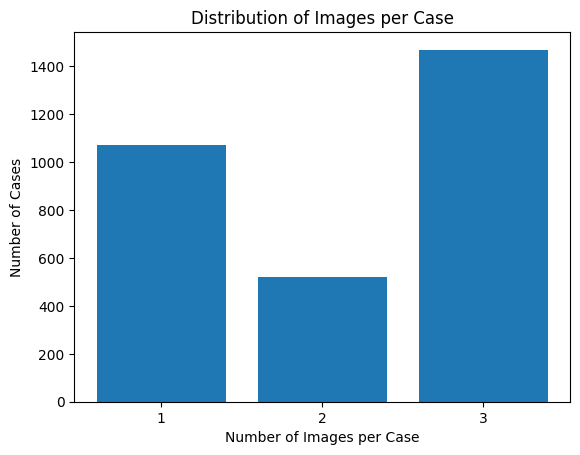

num_images
1    1073
2     519
3    1469
Name: count, dtype: int64


In [ ]:
# How many rows have 3 images?

import matplotlib.pyplot as plt

# Count number of available images per case
df_images["num_images"] = (
    df_images[["image_1_path", "image_2_path", "image_3_path"]]
    .notna()
    .sum(axis=1)
)

# Count how many cases have 1, 2, or 3 images
image_count_distribution = df_images["num_images"].value_counts().sort_index()

# Plot
plt.figure()
plt.bar(image_count_distribution.index, image_count_distribution.values)
plt.xlabel("Number of Images per Case")
plt.ylabel("Number of Cases")
plt.title("Distribution of Images per Case")
plt.xticks([1, 2, 3])
plt.show()

print(image_count_distribution)

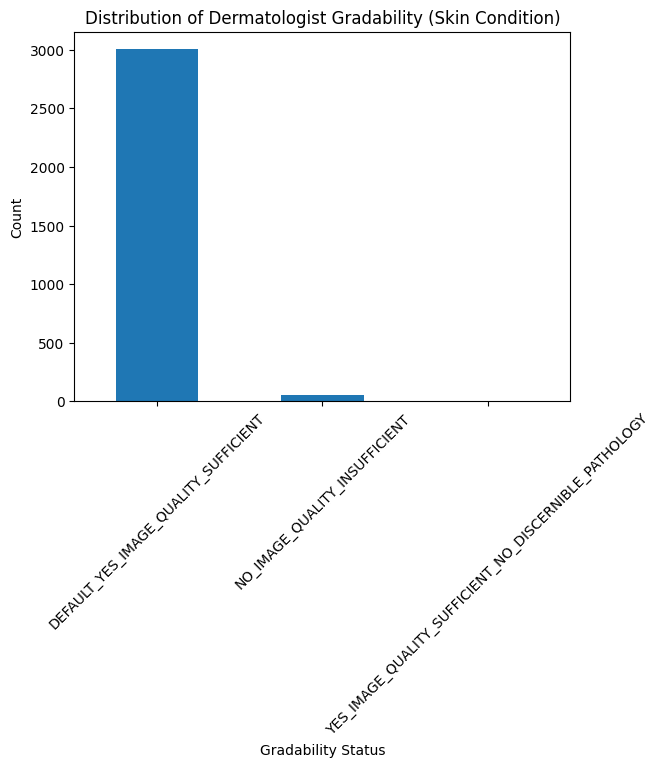

In [ ]:
# Looking at `dermatologist_gradable_for_skin_condition` scores

df['skin_condition_gradable'] = (
    df[['dermatologist_gradable_for_skin_condition_1',
        'dermatologist_gradable_for_skin_condition_2',
        'dermatologist_gradable_for_skin_condition_3']]
    .bfill(axis=1)
    .iloc[:, 0]
)


# Plot
plt.figure()
df['skin_condition_gradable'].value_counts().plot(kind='bar')
plt.title('Distribution of Dermatologist Gradability (Skin Condition)')
plt.xlabel('Gradability Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Removing instances with insufficient image quality

features = [
    'dermatologist_gradable_for_skin_condition_1',
    'dermatologist_gradable_for_skin_condition_2',
    'dermatologist_gradable_for_skin_condition_3'
]

df = df[~df[features].eq('NO_IMAGE_QUALITY_INSUFFICIENT').any(axis=1)]

df.shape[0]

2727

In [ ]:
# What are all the unique classes in the dataset?

from collections import defaultdict

unique_conditions = set()
condition_counts = defaultdict(int)

for val in df["weighted_skin_condition_label"].dropna():
    label_dict = ast.literal_eval(val)

    for condition in label_dict.keys():
        unique_conditions.add(condition)
        condition_counts[condition] += 1

unique_conditions = set(unique_conditions)
condition_counts = dict(condition_counts)

unique_conditions

{'AKV - Acrokeratosis verruciformis',
 'Abrasion and/or friction burn of lower limb without infection',
 'Abrasion of wrist',
 'Abrasion, scrape, or scab',
 'Abscess',
 'Acanthosis nigricans',
 'Acne',
 'Acne keloidalis',
 'Acne urticata',
 'Acneiform eruption',
 'Acquired digital fibrokeratoma',
 'Acral erythema',
 'Acral persistent papular mucinosis',
 'Actinic Keratosis',
 'Actinic granuloma',
 'Acute and chronic dermatitis',
 'Acute dermatitis',
 'Acute dermatitis, NOS',
 'Acute generalised exanthematous pustulosis',
 'Acute ulcer of skin',
 'Acute vesicular dermatitis',
 'Acute-on-chronic dyshidrotic eczema of hands',
 'Adnexal neoplasm',
 'Agminate folliculitis',
 'Allergic Contact Dermatitis',
 'Amyloidosis of skin',
 'Angiokeratoma of skin',
 'Angiosarcoma of skin',
 'Animal bite - wound',
 'Annular erythema',
 'Arsenical keratosis',
 'Atypical Nevus',
 'Autoimmune diseases affecting skin',
 'B-Cell Cutaneous Lymphoma',
 'Bacterial pyoderma',
 'Basal Cell Carcinoma',
 'Benign c

In [ ]:
len(unique_conditions)

337

In [ ]:
list(condition_counts.items())

[('Inflicted skin lesions', 20),
 ('Eczema', 913),
 ('Irritant Contact Dermatitis', 223),
 ('Prurigo nodularis', 17),
 ('SCC/SCCIS', 34),
 ('Actinic Keratosis', 19),
 ('Impetigo', 108),
 ('Herpes Zoster', 126),
 ('Bullous dermatitis', 3),
 ('Lichen planus/lichenoid eruption', 70),
 ('Folliculitis', 226),
 ('Dermatosis due to flea', 2),
 ('Drug Rash', 130),
 ('Viral Exanthem', 70),
 ('Basal Cell Carcinoma', 20),
 ('Psoriasis', 277),
 ('Acute and chronic dermatitis', 46),
 ('Post-Inflammatory hyperpigmentation', 23),
 ('Purpura', 32),
 ('Allergic Contact Dermatitis', 759),
 ('Urticaria', 293),
 ('Skin infection', 12),
 ('Scabies', 47),
 ('Molluscum Contagiosum', 56),
 ('Tinea Versicolor', 48),
 ('Pityriasis rubra pilaris', 7),
 ('Stasis Dermatitis', 59),
 ('Seborrheic Dermatitis', 44),
 ('Insect Bite', 336),
 ('Hyperpigmentation', 1),
 ('Photodermatitis', 35),
 ("Kaposi's sarcoma of skin", 12),
 ('Syphilis', 29),
 ('Infected eczema', 21),
 ('Lichen Simplex Chronicus', 63),
 ('Pityriasis 

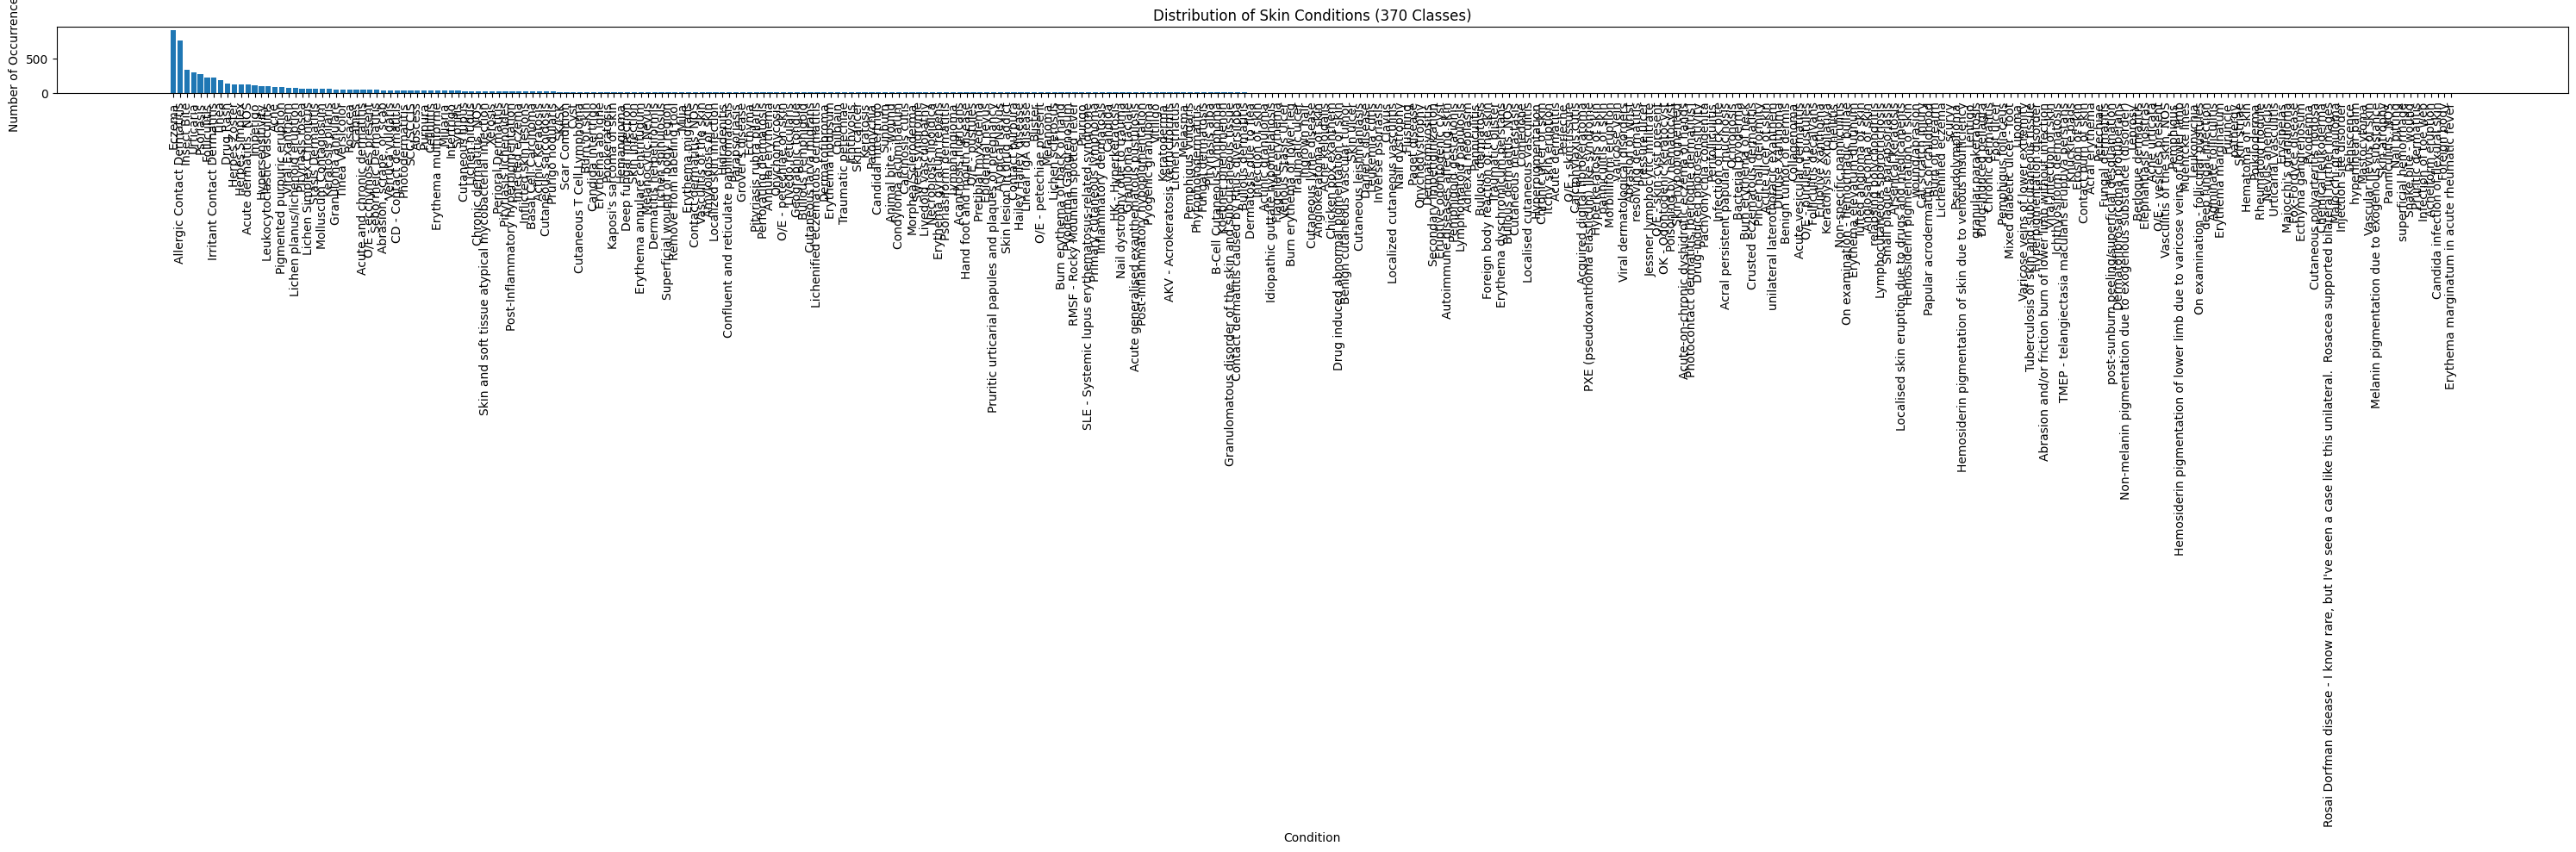

In [ ]:
# Class distribution

# Convert dictionary to DataFrame
df_counts = pd.DataFrame({
    "condition": list(condition_counts.keys()),
    "count": list(condition_counts.values())
})

# Sort by frequency (highest first)
df_counts = df_counts.sort_values("count", ascending=False)

plt.figure(figsize=(30, 10))
plt.bar(df_counts["condition"], df_counts["count"])

plt.xticks(rotation=90)
plt.xlabel("Condition")
plt.ylabel("Number of Occurrences")
plt.title("Distribution of Skin Conditions (370 Classes)")

plt.tight_layout()
plt.show()

In [ ]:
# Label frequency

ranges = {
    "0-10": 0,
    "11-20": 0,
    "21-30": 0,
    "31-50": 0,
    "51-100": 0,
    "101-500": 0,
    "501-1000": 0
}

for count in condition_counts.values():
    if count <= 10:
        ranges["0-10"] += 1
    elif count <= 20:
        ranges["11-20"] += 1
    elif count <= 30:
        ranges["21-30"] += 1
    elif count <= 50:
        ranges["31-50"] += 1
    elif count <= 100:
        ranges["51-100"] += 1
    elif count <= 500:
        ranges["101-500"] += 1
    elif count <= 1000:
        ranges["501-1000"] += 1

print("Label frequencies: ")

for k, v in ranges.items():
    print(f"{k}: {v} labels")



Label frequencies: 
0-10: 264 labels
11-20: 21 labels
21-30: 12 labels
31-50: 15 labels
51-100: 12 labels
101-500: 11 labels
501-1000: 2 labels


## **Collapsing Labels**

In [ ]:
# Collapsing labels - Removing labels with less than 30 instances

import ast

# ---------------------------------------
# STEP 1: Find classes to remove (<50)
# ---------------------------------------

classes_to_remove = []

for condition, count in condition_counts.items():
    if count < 50:
        classes_to_remove.append(condition)

print("Classes to remove:", len(classes_to_remove))


# ---------------------------------------
# STEP 2: Process each row
# ---------------------------------------

new_labels_column = []
new_weights_column = []

for i in range(len(df)):

    # Convert strings to Python objects
    labels = ast.literal_eval(df.iloc[i]["dermatologist_skin_condition_on_label_name"])
    weights = ast.literal_eval(df.iloc[i]["weighted_skin_condition_label"])

    new_labels = []
    new_weights = {}

    removed_weight = 0

    # -------------------------------
    # Remove rare classes from labels
    # -------------------------------

    for condition in labels:
        if condition not in classes_to_remove:
            new_labels.append(condition)

    # --------------------------------
    # Remove rare classes from weights
    # --------------------------------

    for condition, wt in weights.items():

        if condition not in classes_to_remove:
            new_weights[condition] = wt
        else:
            removed_weight += wt


    # --------------------------------
    # Renormalize remaining weights
    # --------------------------------

    if len(new_weights) > 0:

        total_remaining_weight = sum(new_weights.values())

        for condition in new_weights:
            new_weights[condition] = new_weights[condition] / total_remaining_weight


    # Save results
    new_labels_column.append(new_labels)
    new_weights_column.append(new_weights)


# ---------------------------------------
# STEP 3: Add results back to dataframe
# ---------------------------------------

df["filtered_conditions"] = new_labels_column
df["filtered_weights"] = new_weights_column


# ---------------------------------------
# STEP 4: Remove rows with no labels left
# ---------------------------------------

df = df[df["filtered_conditions"].apply(lambda x: len(x) > 0)].reset_index(drop=True)

print("Remaining rows:", len(df))

Classes to remove: 312
Remaining rows: 2390


## **Data Cleaning**

In [ ]:
# Looking at the ordinal features in the data

print("Condition Duration Values:")
print(sorted(df["condition_duration"].dropna().unique()))

print("\nAge Group Values:")
print(sorted(df["age_group"].dropna().unique()))

Condition Duration Values:
['LESS_THAN_ONE_WEEK', 'MORE_THAN_FIVE_YEARS', 'MORE_THAN_ONE_YEAR', 'ONE_DAY', 'ONE_TO_FOUR_WEEKS', 'ONE_TO_THREE_MONTHS', 'SINCE_CHILDHOOD', 'THREE_TO_TWELVE_MONTHS', 'UNKNOWN']

Age Group Values:
['AGE_18_TO_29', 'AGE_30_TO_39', 'AGE_40_TO_49', 'AGE_50_TO_59', 'AGE_60_TO_69', 'AGE_70_TO_79', 'AGE_UNKNOWN']


In [ ]:
# Encoding features


# ---------------------------------------
# STEP 1: 1 Hot Encoding Nominal Features
# ---------------------------------------
df_encoded = pd.get_dummies(
    df,
    columns=[
        "sex_at_birth",
        "related_category",
        "image_1_shot_type",
        "image_2_shot_type",
        "image_3_shot_type"
    ],
    drop_first=False  # Keep all categories
)


# ---------------------------------------
# STEP 2: Label Encoding Ordinal Features
# ---------------------------------------

# Condition Duration Mapping
duration_mapping = {
    "ONE_DAY": 0,
    "LESS_THAN_ONE_WEEK": 1,
    "ONE_TO_FOUR_WEEKS": 2,
    "ONE_TO_THREE_MONTHS": 3,
    "THREE_TO_TWELVE_MONTHS": 4,
    "MORE_THAN_ONE_YEAR": 5,
    "MORE_THAN_FIVE_YEARS": 6,
    "SINCE_CHILDHOOD": 7,
    "UNKNOWN": -1
}

df_encoded["condition_duration"] = df_encoded["condition_duration"].map(duration_mapping).fillna(-1)


# Age Group Mapping
age_mapping = {
    "AGE_18_TO_29": 0,
    "AGE_30_TO_39": 1,
    "AGE_40_TO_49": 2,
    "AGE_50_TO_59": 3,
    "AGE_60_TO_69": 4,
    "AGE_70_TO_79": 5,
    "AGE_UNKNOWN": -1
}


# Fitzpatrick Skin Type Mapping (Ordinal + Flag)

# Ordinal mapping
fst_mapping = {
    "FST1": 1,
    "FST2": 2,
    "FST3": 3,
    "FST4": 4,
    "FST5": 5,
    "FST6": 6,
    "NONE_IDENTIFIED": 0
}

df_encoded["fitzpatrick_skin_type_ordinal"] = df_encoded["fitzpatrick_skin_type"].map(fst_mapping)


# Binary flag for missing / unidentified
df_encoded["fitzpatrick_none_identified"] = (
    df_encoded["fitzpatrick_skin_type"] == "NONE_IDENTIFIED"
).astype(int)


# Drop original column
df_encoded = df_encoded.drop(columns=["fitzpatrick_skin_type"])

df_encoded["age_group"] = df_encoded["age_group"].map(age_mapping)


df_encoded.head()

,case_id,source,release,year,age_group,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,race_ethnicity_hispanic_latino_or_spanish_origin,race_ethnicity_middle_eastern_or_north_african,...,image_1_shot_type_AT_DISTANCE,image_1_shot_type_CLOSE_UP,image_2_shot_type_AT_AN_ANGLE,image_2_shot_type_AT_DISTANCE,image_2_shot_type_CLOSE_UP,image_3_shot_type_AT_AN_ANGLE,image_3_shot_type_AT_DISTANCE,image_3_shot_type_CLOSE_UP,fitzpatrick_skin_type_ordinal,fitzpatrick_none_identified
0,-1000600354148496558,SCIN,1.0.0,2023,-1,NaN,NaN,NaN,NaN,NaN,...,False,True,False,False,False,False,False,False,NaN,0
1,-1003358831658393077,SCIN,1.0.0,2023,0,NaN,NaN,NaN,YES,NaN,...,False,True,False,False,False,False,False,False,0.0,1
2,-1003844406100696311,SCIN,1.0.0,2023,2,NaN,NaN,NaN,NaN,NaN,...,False,False,False,True,False,False,False,True,3.0,0
3,-1005079160214352144,SCIN,1.0.0,2023,-1,NaN,NaN,NaN,NaN,NaN,...,False,True,True,False,False,False,True,False,NaN,0
4,-101827005996397499,SCIN,1.0.0,2023,0,NaN,NaN,NaN,YES,NaN,...,False,True,True,False,False,False,False,False,2.0,0


In [ ]:
df_encoded.shape

(2390, 94)

In [ ]:
# How does a row look like now?

row = df_encoded.head(1)

for item in row:
  print(f'{item} : {row[item].values[0]}')

case_id : -1000600354148496558
source : SCIN
release : 1.0.0
year : 2023
age_group : -1
race_ethnicity_american_indian_or_alaska_native : nan
race_ethnicity_asian : nan
race_ethnicity_black_or_african_american : nan
race_ethnicity_hispanic_latino_or_spanish_origin : nan
race_ethnicity_middle_eastern_or_north_african : nan
race_ethnicity_native_hawaiian_or_pacific_islander : nan
race_ethnicity_white : nan
race_ethnicity_other_race : nan
race_ethnicity_prefer_not_to_answer : nan
textures_raised_or_bumpy : YES
textures_flat : nan
textures_rough_or_flaky : nan
textures_fluid_filled : nan
body_parts_head_or_neck : nan
body_parts_arm : nan
body_parts_palm : nan
body_parts_back_of_hand : nan
body_parts_torso_front : nan
body_parts_torso_back : nan
body_parts_genitalia_or_groin : nan
body_parts_buttocks : nan
body_parts_leg : nan
body_parts_foot_top_or_side : YES
body_parts_foot_sole : nan
body_parts_other : nan
condition_symptoms_bothersome_appearance : nan
condition_symptoms_bleeding : YES
c

In [ ]:
pd.set_option('display.max_rows', None)
df_encoded.dtypes

,0
case_id,int64
source,object
release,object
year,int64
age_group,int64
race_ethnicity_american_indian_or_alaska_native,object
race_ethnicity_asian,object
race_ethnicity_black_or_african_american,object
race_ethnicity_hispanic_latino_or_spanish_origin,object
race_ethnicity_middle_eastern_or_north_african,object


In [ ]:
# How does object columns look like?

object_cols = df_encoded.select_dtypes(include="object").columns # Getting all the object columns

# Identify columns that are known to contain lists or dicts
list_or_dict_cols = [
    'dermatologist_skin_condition_on_label_name',
    'dermatologist_skin_condition_confidence',
    'weighted_skin_condition_label',
    'filtered_conditions',
    'filtered_weights'
]

print("Values of the object columns: ")
for col in object_cols:
    if col in list_or_dict_cols:
        print(f'{col}: [Contains lists/dicts, showing first 5 non-null entries]')
        # Print a few non-null entries to show their structure
        for item in df_encoded[col].dropna().head(5):
            print(f'  - {item}')
    else:
        print(f'{col}: {df_encoded[col].unique()}')

# Distribution of values in the object columns
print("\nDistribution of values in the object columns: ")
for col in object_cols:
    print(f"\nColumn: {col}")
    # For list/dict columns, value_counts might not be meaningful or can be slow.
    # We'll just show the head of value_counts, as it might still provide some insight for certain cases.
    print(df_encoded[col].value_counts(dropna=False).head(10))


Values of the object columns: 
source: ['SCIN']
release: ['1.0.0']
race_ethnicity_american_indian_or_alaska_native: [nan 'YES']
race_ethnicity_asian: [nan 'YES']
race_ethnicity_black_or_african_american: [nan 'YES']
race_ethnicity_hispanic_latino_or_spanish_origin: [nan 'YES']
race_ethnicity_middle_eastern_or_north_african: [nan 'YES']
race_ethnicity_native_hawaiian_or_pacific_islander: [nan 'YES']
race_ethnicity_white: [nan 'YES']
race_ethnicity_other_race: [nan 'YES']
race_ethnicity_prefer_not_to_answer: [nan 'YES']
textures_raised_or_bumpy: ['YES' nan]
textures_flat: [nan 'YES']
textures_rough_or_flaky: [nan 'YES']
textures_fluid_filled: [nan 'YES']
body_parts_head_or_neck: [nan 'YES']
body_parts_arm: [nan 'YES']
body_parts_palm: [nan 'YES']
body_parts_back_of_hand: [nan 'YES']
body_parts_torso_front: [nan 'YES']
body_parts_torso_back: [nan 'YES']
body_parts_genitalia_or_groin: [nan 'YES']
body_parts_buttocks: [nan 'YES']
body_parts_leg: [nan 'YES']
body_parts_foot_top_or_side: ['YE

In [ ]:
# How does boolean columns look like?

bool_cols = df_encoded.select_dtypes(include="bool").columns # Getting all the boolean columns

# All the unique values in boolean columns
for col in bool_cols:
    print(f"{col}: {df_encoded[col].unique()}")

sex_at_birth_FEMALE: [False  True]
sex_at_birth_MALE: [False  True]
sex_at_birth_OTHER_OR_UNSPECIFIED: [ True False]
related_category_ACNE: [False  True]
related_category_GROWTH_OR_MOLE: [False  True]
related_category_HAIR_LOSS: [False  True]
related_category_LOOKS_HEALTHY: [False  True]
related_category_NAIL_PROBLEM: [False  True]
related_category_OTHER_HAIR_PROBLEM: [False  True]
related_category_OTHER_ISSUE_DESCRIPTION: [False  True]
related_category_PIGMENTARY_PROBLEM: [False  True]
related_category_RASH: [ True False]
image_1_shot_type_AT_AN_ANGLE: [False  True]
image_1_shot_type_AT_DISTANCE: [False  True]
image_1_shot_type_CLOSE_UP: [ True False]
image_2_shot_type_AT_AN_ANGLE: [False  True]
image_2_shot_type_AT_DISTANCE: [False  True]
image_2_shot_type_CLOSE_UP: [False  True]
image_3_shot_type_AT_AN_ANGLE: [False  True]
image_3_shot_type_AT_DISTANCE: [False  True]
image_3_shot_type_CLOSE_UP: [False  True]


In [ ]:
# ---------------------------------------
# STEP: Convert Binary Object + Bool → 0/1
# ---------------------------------------

import numpy as np

# 1. Columns with YES / NaN → 1 / 0
yes_nan_cols = [
    # Race
    "race_ethnicity_american_indian_or_alaska_native",
    "race_ethnicity_asian",
    "race_ethnicity_black_or_african_american",
    "race_ethnicity_hispanic_latino_or_spanish_origin",
    "race_ethnicity_middle_eastern_or_north_african",
    "race_ethnicity_native_hawaiian_or_pacific_islander",
    "race_ethnicity_white",
    "race_ethnicity_other_race",
    "race_ethnicity_prefer_not_to_answer",
    "race_ethnicity_two_or_more_after_mitigation",

    # Texture
    "textures_raised_or_bumpy",
    "textures_flat",
    "textures_rough_or_flaky",
    "textures_fluid_filled",

    # Body parts
    "body_parts_head_or_neck",
    "body_parts_arm",
    "body_parts_palm",
    "body_parts_back_of_hand",
    "body_parts_torso_front",
    "body_parts_torso_back",
    "body_parts_genitalia_or_groin",
    "body_parts_buttocks",
    "body_parts_leg",
    "body_parts_foot_top_or_side",
    "body_parts_foot_sole",
    "body_parts_other",

    # Condition symptoms
    "condition_symptoms_bothersome_appearance",
    "condition_symptoms_bleeding",
    "condition_symptoms_increasing_size",
    "condition_symptoms_darkening",
    "condition_symptoms_itching",
    "condition_symptoms_burning",
    "condition_symptoms_pain",
    "condition_symptoms_no_relevant_experience",

    # Other symptoms
    "other_symptoms_fever",
    "other_symptoms_chills",
    "other_symptoms_fatigue",
    "other_symptoms_joint_pain",
    "other_symptoms_mouth_sores",
    "other_symptoms_shortness_of_breath",
    "other_symptoms_no_relevant_symptoms",
]

for col in yes_nan_cols:
    df_encoded[col] = df_encoded[col].map({"YES": 1}).fillna(0).astype(int)


# 2. Columns with YES / NO / NaN → 1 / 0 / 0
yes_no_cols = [
    "dermatologist_gradable_for_fitzpatrick_skin_type_1",
    "dermatologist_gradable_for_fitzpatrick_skin_type_2",
    "dermatologist_gradable_for_fitzpatrick_skin_type_3",
]

for col in yes_no_cols:
    df_encoded[col] = df_encoded[col].map({"YES": 1, "NO": 0}).fillna(0).astype(int)


# 3. Boolean columns → 1 / 0
bool_cols = df_encoded.select_dtypes(include="bool").columns

for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)


# 4. Mixed bool + NaN columns (Monk skin tone)
mixed_bool_cols = [
    "gradable_for_monk_skin_tone_india",
    "gradable_for_monk_skin_tone_us",
]

for col in mixed_bool_cols:
    df_encoded[col] = df_encoded[col].fillna(False).astype(int)


# Sanity Check 😭
print("Remaining object columns:", df_encoded.select_dtypes(include="object").columns)

Remaining object columns: Index(['source', 'release', 'image_1_path', 'image_2_path', 'image_3_path',
       'combined_race', 'dermatologist_gradable_for_skin_condition_1',
       'dermatologist_gradable_for_skin_condition_2',
       'dermatologist_gradable_for_skin_condition_3',
       'dermatologist_skin_condition_on_label_name',
       'dermatologist_skin_condition_confidence',
       'weighted_skin_condition_label',
       'dermatologist_fitzpatrick_skin_type_label_1',
       'dermatologist_fitzpatrick_skin_type_label_2',
       'dermatologist_fitzpatrick_skin_type_label_3',
       'skin_condition_gradable', 'filtered_conditions', 'filtered_weights'],
      dtype='object')


/tmp/ipykernel_480/535547810.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded[col] = df_encoded[col].fillna(False).astype(int)
/tmp/ipykernel_480/535547810.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded[col] = df_encoded[col].fillna(False).astype(int)


In [ ]:
df_encoded.columns

Index(['case_id', 'source', 'release', 'year', 'age_group',
       'race_ethnicity_american_indian_or_alaska_native',
       'race_ethnicity_asian', 'race_ethnicity_black_or_african_american',
       'race_ethnicity_hispanic_latino_or_spanish_origin',
       'race_ethnicity_middle_eastern_or_north_african',
       'race_ethnicity_native_hawaiian_or_pacific_islander',
       'race_ethnicity_white', 'race_ethnicity_other_race',
       'race_ethnicity_prefer_not_to_answer', 'textures_raised_or_bumpy',
       'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled',
       'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm',
       'body_parts_back_of_hand', 'body_parts_torso_front',
       'body_parts_torso_back', 'body_parts_genitalia_or_groin',
       'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side',
       'body_parts_foot_sole', 'body_parts_other',
       'condition_symptoms_bothersome_appearance',
       'condition_symptoms_bleeding', 'cond

## **Creating input and output datasets(X, y)**

In [ ]:
# Input data(X)

# Columns to exclude
exclude_cols = [
    # ---------------------------------------
    # Output-related (target leakage)
    # ---------------------------------------
    "filtered_conditions",
    "filtered_weights",
    "dermatologist_skin_condition_on_label_name",
    "weighted_skin_condition_label",
    "dermatologist_skin_condition_confidence",

    # ---------------------------------------
    # Redundant / derived
    # ---------------------------------------
    "combined_race",
    "race_ethnicity_two_or_more_after_mitigation",

    # ---------------------------------------
    # Metadata / useless
    # ---------------------------------------
    "source",
    "release",
    "year",

    # ---------------------------------------
    # Image paths (handled separately)
    # ---------------------------------------
    "image_1_path",
    "image_2_path",
    "image_3_path",

    # ---------------------------------------
    # Dermatologist-only (HARD LEAKAGE)
    # ---------------------------------------
    "dermatologist_gradable_for_skin_condition_1",
    "dermatologist_gradable_for_skin_condition_2",
    "dermatologist_gradable_for_skin_condition_3",

    "dermatologist_gradable_for_fitzpatrick_skin_type_1",
    "dermatologist_gradable_for_fitzpatrick_skin_type_2",
    "dermatologist_gradable_for_fitzpatrick_skin_type_3",

    "dermatologist_fitzpatrick_skin_type_label_1",
    "dermatologist_fitzpatrick_skin_type_label_2",
    "dermatologist_fitzpatrick_skin_type_label_3",

    # ---------------------------------------
    # Already used / no signal
    # ---------------------------------------
    "skin_condition_gradable",
    "num_diagnoses",

    # ---------------------------------------
    # Derived / leakage-prone categories
    # ---------------------------------------
    "related_category_ACNE",
    "related_category_GROWTH_OR_MOLE",
    "related_category_HAIR_LOSS",
    "related_category_LOOKS_HEALTHY",
    "related_category_NAIL_PROBLEM",
    "related_category_OTHER_HAIR_PROBLEM",
    "related_category_OTHER_ISSUE_DESCRIPTION",
    "related_category_PIGMENTARY_PROBLEM",
    "related_category_RASH",

    # ---------------------------------------
    # Image metadata (SPURIOUS SIGNAL)
    # ---------------------------------------
    "image_1_shot_type_AT_AN_ANGLE",
    "image_1_shot_type_AT_DISTANCE",
    "image_1_shot_type_CLOSE_UP",
    "image_2_shot_type_AT_AN_ANGLE",
    "image_2_shot_type_AT_DISTANCE",
    "image_2_shot_type_CLOSE_UP",
    "image_3_shot_type_AT_AN_ANGLE",
    "image_3_shot_type_AT_DISTANCE",
    "image_3_shot_type_CLOSE_UP",

    # ---------------------------------------
    # Skin tone (not user-provided)
    # ---------------------------------------
    "monk_skin_tone_label_india",
    "monk_skin_tone_label_us",
    "gradable_for_monk_skin_tone_india",
    "gradable_for_monk_skin_tone_us",

    # ---------------------------------------
    # Fitzpatrick (NOT user-friendly input)
    # ---------------------------------------
    "fitzpatrick_skin_type_ordinal",
    "fitzpatrick_none_identified",

    # ---------------------------------------
    # Redundant "no symptom" flags
    # ---------------------------------------
    "condition_symptoms_no_relevant_experience",
    "other_symptoms_no_relevant_symptoms",
]

X = df_encoded.drop(columns=exclude_cols, errors="ignore").copy()

X["case_id"] = X["case_id"].astype("int64") # Let case_id be a integer for easy tracking of training and test sets

# Convert ALL other columns to float32
for col in X.columns:
    if col != "case_id":
        X[col] = X[col].astype("float32")


X.head()


,case_id,age_group,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,race_ethnicity_hispanic_latino_or_spanish_origin,race_ethnicity_middle_eastern_or_north_african,race_ethnicity_native_hawaiian_or_pacific_islander,race_ethnicity_white,race_ethnicity_other_race,...,other_symptoms_fever,other_symptoms_chills,other_symptoms_fatigue,other_symptoms_joint_pain,other_symptoms_mouth_sores,other_symptoms_shortness_of_breath,condition_duration,sex_at_birth_FEMALE,sex_at_birth_MALE,sex_at_birth_OTHER_OR_UNSPECIFIED
0,-1000600354148496558,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1003358831658393077,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0
2,-1003844406100696311,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-1005079160214352144,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-101827005996397499,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0


In [ ]:
# Check

X.dtypes

,0
case_id,int64
age_group,float32
race_ethnicity_american_indian_or_alaska_native,float32
race_ethnicity_asian,float32
race_ethnicity_black_or_african_american,float32
race_ethnicity_hispanic_latino_or_spanish_origin,float32
race_ethnicity_middle_eastern_or_north_african,float32
race_ethnicity_native_hawaiian_or_pacific_islander,float32
race_ethnicity_white,float32
race_ethnicity_other_race,float32


In [ ]:
# Output data(y)

# ---------------------------------------
# STEP 1: Get all unique conditions
# ---------------------------------------
all_conditions = set()

for d in df_encoded["filtered_weights"]:
    all_conditions.update(d.keys())

all_conditions = sorted(list(all_conditions))

print("Total conditions:", len(all_conditions))


# ---------------------------------------
# STEP 2: Create empty output matrix
# ---------------------------------------
import pandas as pd

y = pd.DataFrame(0.0, index=df_encoded.index, columns=all_conditions, dtype="float32")


# ---------------------------------------
# STEP 3: Fill weights
# ---------------------------------------
for i, d in enumerate(df_encoded["filtered_weights"]):
    for condition, weight in d.items():
        y.at[i, condition] = weight


# ---------------------------------------
# STEP 4: Add case_id for tracking
# ---------------------------------------
y.insert(0, "case_id", df_encoded["case_id"])

y["case_id"] = y["case_id"].astype("int64") # Let case_id be a integer for easy tracking of training and test sets

Total conditions: 25


In [ ]:
y.head()

,case_id,Acne,"Acute dermatitis, NOS",Allergic Contact Dermatitis,Drug Rash,Eczema,Folliculitis,Granuloma annulare,Herpes Simplex,Herpes Zoster,...,Lichen Simplex Chronicus,Lichen planus/lichenoid eruption,Molluscum Contagiosum,Pigmented purpuric eruption,Pityriasis rosea,Psoriasis,Stasis Dermatitis,Tinea,Urticaria,Viral Exanthem
0,-1000600354148496558,0.0,0.0,0.0,0.00,0.694915,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00
1,-1003358831658393077,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,0.294872,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00
2,-1003844406100696311,0.0,0.0,0.0,0.00,0.000000,0.5,0.0,0.0,0.000000,...,0.0,0.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00
3,-1005079160214352144,0.0,0.0,0.0,0.41,0.180000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.41
4,-101827005996397499,0.0,0.0,0.0,0.00,0.858974,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.141026,0.0,0.0,0.0,0.00


In [ ]:
# Check row sum (should be ~1 or <=1)
print(y.drop(columns=["case_id"]).sum(axis=1).head())

# Check no NaNs
print("NaNs in y:", y.isna().sum().sum())

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float32
NaNs in y: 0


In [ ]:
# Check

y.dtypes

,0
case_id,int64
Acne,float32
"Acute dermatitis, NOS",float32
Allergic Contact Dermatitis,float32
Drug Rash,float32
Eczema,float32
Folliculitis,float32
Granuloma annulare,float32
Herpes Simplex,float32
Herpes Zoster,float32


In [ ]:
# Sanity Check 😭

# X check
non_float_cols_X = [
    col for col in X.columns
    if col != "case_id" and X[col].dtype != "float32"
]

# y check
non_float_cols_y = [
    col for col in y.columns
    if col != "case_id" and y[col].dtype != "float32"
]

non_float_cols_X, non_float_cols_X

([], [])

## **Creating a image dataset**

In [ ]:
# Creating a dataset with image links

df_images = df_encoded[[
    "case_id",
    "image_1_path",
    "image_2_path",
    "image_3_path"
]].copy()

df_images.head()

,case_id,image_1_path,image_2_path,image_3_path
0,-1000600354148496558,dataset/images/-3205742176803893704.png,NaN,NaN
1,-1003358831658393077,dataset/images/-4027806997035329030.png,NaN,NaN
2,-1003844406100696311,dataset/images/-3799298995660217860.png,dataset/images/-5881426422999442186.png,dataset/images/5854025080806696361.png
3,-1005079160214352144,dataset/images/-3575683440831198879.png,dataset/images/6164754101533643044.png,dataset/images/7125798012232703466.png
4,-101827005996397499,dataset/images/-217828380359571871.png,dataset/images/-4055728304670056584.png,NaN


## **Creating train and test sets using multilabel stratification**

In [ ]:
!pip install iterative-stratification

In [ ]:
# Splitting

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# ---------------------------------------
# STEP 1: Separate features and labels
# ---------------------------------------

X_data = X.copy()
y_data = y.copy()

# Drop case_id for stratification logic
X_features = X_data.drop(columns=["case_id"])
y_features = y_data.drop(columns=["case_id"])


# ---------------------------------------
# STEP 2: Multilabel Stratified Split
# ---------------------------------------

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in msss.split(X_features, y_features):
    X_train = X_data.iloc[train_idx].copy()
    X_test  = X_data.iloc[test_idx].copy()

    y_train = y_data.iloc[train_idx].copy()
    y_test  = y_data.iloc[test_idx].copy()


# ---------------------------------------
# STEP 3: Extract IDs
# ---------------------------------------

train_ids = X_train["case_id"].copy()
test_ids  = X_test["case_id"].copy()


# ---------------------------------------
# STEP 4: Sanity Checks
# ---------------------------------------

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# Check alignment
print("\nID alignment check:")
print((X_train["case_id"].values == y_train["case_id"].values).all())
print((X_test["case_id"].values == y_test["case_id"].values).all())

Train shape: (1904, 44) (1904, 26)
Test shape: (486, 44) (486, 26)

ID alignment check:
True
True


# ***Phase-3: Classification Model***

**We will build the following classification models for the tabular data:**
- A multi-label Ridge Regressor Model (baseline).
- A LightGBM regressor for multi-label classification.
- A milti-label knn regressor.
- An Elastic Net regressor for multi-labeel classification.
- A shallow FNN with weighted classification head.

<br>

**We will choose the best performing model for the next step.**

In [ ]:
# Wrapper function to convert the output vector into a list
def prediction_to_dict(pred_vector, label_columns, threshold=0.01):
    result = {}

    for i, label in enumerate(label_columns):
        value = float(pred_vector[i])

        if value > threshold:
            result[label] = value

    return result

In [ ]:
# Code to calculate Top-K-Accuracy
import numpy as np

def top_k_accuracy(y_true, y_pred, k=3):
    correct = 0

    for i in range(len(y_true)):
        true_labels = set(np.where(y_true[i] > 0)[0])
        top_k_pred = set(np.argsort(y_pred[i])[-k:])

        if len(true_labels & top_k_pred) > 0:
            correct += 1

    return correct / len(y_true)


## **Multi-label Ridge Regressor (baseline)**

In [ ]:
# Creating the train and test datasets
from sklearn.preprocessing import StandardScaler

# Input Data
X_train_baseline = X_train.drop(columns=["case_id"]).copy()
X_test_baseline  = X_test.drop(columns=["case_id"]).copy()

# Output Data
label_columns = y_train.columns.drop("case_id")
y_train_baseline = y_train[label_columns].values
y_test_baseline  = y_test[label_columns].values

# Scaling the input data
scaler = StandardScaler()
X_train_baseline = scaler.fit_transform(X_train_baseline)
X_test_baseline  = scaler.transform(X_test_baseline)

In [ ]:
# Baseline Model
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np


ridge = MultiOutputRegressor(Ridge()) # Baseline Model


param_grid = {
    "estimator__alpha": [0.1, 1.0, 10.0, 50.0] # Hyperparameter grid
}


grid = GridSearchCV( # Grid Search
    ridge,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_baseline, y_train_baseline)


ridge_model = grid.best_estimator_ # Best Model

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Params: {'estimator__alpha': 50.0}


In [ ]:
# Error Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.special import softmax

# Make Predictions
y_pred_baseline = ridge_model.predict(X_test_baseline)

# Normalize
y_pred_baseline = softmax(y_pred_baseline, axis=1)

# Top K Accuracy
print("Top-1 Accuracy:", top_k_accuracy(y_test_baseline, y_pred_baseline, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_test_baseline, y_pred_baseline, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_test_baseline, y_pred_baseline, k=5))

# MAE and MSE
mse = mean_squared_error(y_test_baseline, y_pred_baseline)
mae = mean_absolute_error(y_test_baseline, y_pred_baseline)

print("MSE:", mse)
print("MAE:", mae)

Top-1 Accuracy: 0.35826771653543305
Top-3 Accuracy: 0.6358267716535433
Top-5 Accuracy: 0.7696850393700787
MSE: 0.02053798921406269
MAE: 0.06017155945301056


## **LightGBM Multi-label Regressor**

In [ ]:
# Creating train and test datasets

# Drop non-feature columns
X_train_lgbm = X_train.drop(columns=["case_id"])
X_test_lgbm = X_test.drop(columns=["case_id"])

y_train_lgbm = y_train.drop(columns=["case_id"])
y_test_lgbm = y_test.drop(columns=["case_id"])

# Convert to numpy (optional)
X_train_lgbm = X_train_lgbm.copy()
X_test_lgbm = X_test_lgbm.copy()
y_train_lgbm = y_train_lgbm.values.copy()
y_test_lgbm = y_test_lgbm.values.copy()

In [ ]:
# LightGBM Model
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV


# Base model
lgbm = LGBMRegressor(
    objective='regression',
    n_jobs=-1
)

# Multi-label wrapper
multi_lgbm = MultiOutputRegressor(lgbm)

# Hyperparameter Grid
param_dist = {
    "estimator__n_estimators": [100, 150, 200],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__num_leaves": [31, 63]
}

# Randomized Search
random_search_lgbm = RandomizedSearchCV(
    estimator=multi_lgbm,
    param_distributions=param_dist,
    n_iter=6,
    scoring='neg_mean_squared_error',
    cv=2,
    verbose=2,
    n_jobs=-1,
    random_state=42
)


# Train
random_search_lgbm.fit(X_train_lgbm, y_train_lgbm)

# Best Params
print("Best Parameters:", random_search_lgbm.best_params_)

# Best Model
lgbm_model = random_search_lgbm.best_estimator_

Fitting 2 folds for each of 6 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.027410
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000655 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.147761


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.039733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.012341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak m

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.014549
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.013768
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000534 seconds.
You can set `fo

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak m

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.057980
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 38
[LightGBM] [Info] Start training from score 0.010233
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [ ]:
# Error Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.special import softmax

# Make Predictions
y_pred_lgbm = lgbm_model.predict(X_test_lgbm)

# Normalize
y_pred_lgbm = softmax(y_pred_lgbm, axis=1)

# Top K Accuracy
print("Top-1 Accuracy:", top_k_accuracy(y_test_lgbm, y_pred_lgbm, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_test_lgbm, y_pred_lgbm, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_test_lgbm, y_pred_lgbm, k=5))

# MAE and MSE
mse_lgbm = mean_squared_error(y_test_lgbm, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test_lgbm, y_pred_lgbm)

print("MSE:", mse_lgbm)
print("MAE:", mae_lgbm)

Top-1 Accuracy: 0.36213991769547327
Top-3 Accuracy: 0.6481481481481481
Top-5 Accuracy: 0.7695473251028807
MSE: 0.025593963564508826
MAE: 0.07334013681556184


## **Multilabel KNN Regressor**

In [ ]:
# Creating the train and test datasets
from sklearn.preprocessing import StandardScaler

# Input Data
X_train_knn= X_train.drop(columns=["case_id"]).copy()
X_test_knn  = X_test.drop(columns=["case_id"]).copy()

# Output Data
label_columns = y_train.columns.drop("case_id")
y_train_knn = y_train[label_columns].values
y_test_knn  = y_test[label_columns].values

# Scaling the input data
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_knn)
X_test_knn  = scaler.transform(X_test_knn)

In [ ]:
# KNN Model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV

# Base model
knn = KNeighborsRegressor()

# Wrap for multi-label
multi_knn = MultiOutputRegressor(knn)

# Hyperparameter grid
param_grid = {
    "estimator__n_neighbors": [3, 5, 7, 11],
    "estimator__weights": ["uniform", "distance"],
    "estimator__p": [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# Grid Search
grid_knn = GridSearchCV(
    multi_knn,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_knn.fit(X_train_knn, y_train_knn)

# Best model
knn_model = grid_knn.best_estimator_

print("Best Params:", grid_knn.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'estimator__n_neighbors': 11, 'estimator__p': 1, 'estimator__weights': 'uniform'}


In [ ]:
# Error Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make Predictions
y_pred_knn = knn_model.predict(X_test_knn)

# Normalize
y_pred_knn = softmax(y_pred_knn, axis=1)

# Top K Accuracy
print("Top-1 Accuracy:", top_k_accuracy(y_test_knn, y_pred_knn, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_test_knn, y_pred_knn, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_test_knn, y_pred_knn, k=5))

# MAE and MSE
mse_knn = mean_squared_error(y_test_knn, y_pred_knn)
mae_knn = mean_absolute_error(y_test_knn, y_pred_knn)

print("MSE:", mse_knn)
print("MAE:", mae_knn)

Top-1 Accuracy: 0.33661417322834647
Top-3 Accuracy: 0.6062992125984252
Top-5 Accuracy: 0.6811023622047244
MSE: 0.020524127408862114
MAE: 0.06014997512102127


## **Elastic Net for Multi-label classification**

In [ ]:
# Creating the train and test datasets
from sklearn.preprocessing import StandardScaler

# Input Data
X_train_elastic = X_train.drop(columns=["case_id"]).copy()
X_test_elastic  = X_test.drop(columns=["case_id"]).copy()

# Output Data
label_columns = y_train.columns.drop("case_id")
y_train_elastic = y_train[label_columns].values
y_test_elastic  = y_test[label_columns].values

# Scaling the input data
scaler = StandardScaler()
X_train_elastic = scaler.fit_transform(X_train_elastic)
X_test_elastic  = scaler.transform(X_test_elastic)

In [ ]:
# Elastic Net Model
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV

elastic = MultiOutputRegressor(ElasticNet(max_iter=5000))

param_grid = {
    "estimator__alpha": [0.01, 0.1, 1.0, 10.0],   # strength of regularization
    "estimator__l1_ratio": [0.2, 0.5, 0.8]        # mix of L1 (sparse) + L2 (ridge)
}

grid = GridSearchCV(
    elastic,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_elastic, y_train_elastic)

elastic_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'estimator__alpha': 0.01, 'estimator__l1_ratio': 0.5}


In [ ]:
# Error Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred_elastic = elastic_model.predict(X_test_elastic)

# Normalize
y_pred_elastic = softmax(y_pred_elastic, axis=1)

# Top-K Accuracy
print("Top-1 Accuracy:", top_k_accuracy(y_test_elastic, y_pred_elastic, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_test_elastic, y_pred_elastic, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_test_elastic, y_pred_elastic, k=5))

# MAE and MSE
mse = mean_squared_error(y_test_elastic, y_pred_elastic)
mae = mean_absolute_error(y_test_elastic, y_pred_elastic)

print("MSE:", mse)
print("MAE:", mae)

Top-1 Accuracy: 0.35236220472440943
Top-3 Accuracy: 0.6476377952755905
Top-5 Accuracy: 0.7696850393700787
MSE: 0.020556610077619553
MAE: 0.06020532548427582


## **Shallow FNN**

In [ ]:
# STEP-1: Creating train/test datasets for FNN
from sklearn.preprocessing import StandardScaler

# Input Data
X_train_fnn = X_train.drop(columns=["case_id"]).copy()
X_test_fnn  = X_test.drop(columns=["case_id"]).copy()

# Output Data
label_columns = y_train.columns.drop("case_id")
y_train_fnn = y_train[label_columns].values
y_test_fnn  = y_test[label_columns].values

# Scale input
scaler = StandardScaler()
X_train_fnn = scaler.fit_transform(X_train_fnn)
X_test_fnn  = scaler.transform(X_test_fnn)

In [ ]:
# STEP-2: FNN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_features = X_train_fnn.shape[1]
num_labels = y_train_fnn.shape[1]

# Build Model
model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(num_features,)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output layer
model.add(Dense(num_labels, activation='softmax'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=tf.keras.losses.KLDivergence(),
    metrics=['cosine_similarity']
)

model.summary()

# Callbacks

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Learning Rate Scheduler
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001)


# Train
history = model.fit(
    X_train_fnn,
    y_train_fnn,
    validation_split=0.1,
    epochs=70,
    batch_size=32,
    verbose=1,
    callbacks = [early_stopping, lr_reducer]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 31)             │         2,015 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,967 (218.62 KB)

 Trainable params: 55,199 (215.62 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - cosine_similarity: 0.2293 - loss: 3.0678 - val_cosine_similarity: 0.2955 - val_loss: 2.6543 - learning_rate: 5.0000e-04
Epoch 2/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 0.3280 - loss: 2.6117 - val_cosine_similarity: 0.3548 - val_loss: 2.4792 - learning_rate: 5.0000e-04
Epoch 3/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 0.3588 - loss: 2.4671 - val_cosine_similarity: 0.3845 - val_loss: 2.3853 - learning_rate: 5.0000e-04
Epoch 4/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 0.3785 - loss: 2.3827 - val_cosine_similarity: 0.4008 - val_loss: 2.3280 - learning_rate: 5.0000e-04
Epoch 5/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 0.3866 - loss: 2.3228 - val_cosine_similarity: 0.4052 - val_loss: 2.3014 - learning_rate: 5.0000e-04
Epoch 6/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - cosine_similarity: 0.3988 - loss: 2.2775 - val_cosine_similarity: 0.4161 - val_loss: 2

In [ ]:
# STEP-3: Evaluation
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predictions
y_pred_fnn = model.predict(X_test_fnn)

# Top-K Accuracy
print("Top-1 Accuracy:", top_k_accuracy(y_test_fnn, y_pred_fnn, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_test_fnn, y_pred_fnn, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_test_fnn, y_pred_fnn, k=5))

# Error Metrics
mse = mean_squared_error(y_test_fnn, y_pred_fnn)
mae = mean_absolute_error(y_test_fnn, y_pred_fnn)

print("MSE:", mse)
print("MAE:", mae)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Top-1 Accuracy: 0.3346456692913386
Top-3 Accuracy: 0.6259842519685039
Top-5 Accuracy: 0.7519685039370079
MSE: 0.01915086805820465
MAE: 0.05417807772755623


# ***Phase-4: CNN Model***
- We will run multiple modelling experiments on the images and choose the best CNN.

## **Image Download and Proceessing**

In [ ]:
# Filter valid image rows

# Keep only case_ids that exist in df_encoded (final cleaned dataset)

valid_case_ids = set(df_encoded["case_id"])

df_images_selected = df_images[df_images["case_id"].isin(valid_case_ids)].copy()

print("Filtered image rows:", df_images_selected.shape)
df_images_selected.head()

Filtered image rows: (2390, 4)


,case_id,image_1_path,image_2_path,image_3_path
0,-1000600354148496558,dataset/images/-3205742176803893704.png,NaN,NaN
1,-1003358831658393077,dataset/images/-4027806997035329030.png,NaN,NaN
2,-1003844406100696311,dataset/images/-3799298995660217860.png,dataset/images/-5881426422999442186.png,dataset/images/5854025080806696361.png
3,-1005079160214352144,dataset/images/-3575683440831198879.png,dataset/images/6164754101533643044.png,dataset/images/7125798012232703466.png
4,-101827005996397499,dataset/images/-217828380359571871.png,dataset/images/-4055728304670056584.png,NaN


In [50]:
# Download the images

import os
import requests
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

IMAGE_FOLDER = "/content/scin_images"
os.makedirs(IMAGE_FOLDER, exist_ok=True)

base_url = "https://storage.googleapis.com/dx-scin-public-data/"

def download_single_image(args):
    url, save_path = args

    if os.path.exists(save_path):
        return True

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                f.write(response.content)
            return True
    except:
        pass

    return False


# Create download tasks
download_tasks = []

for _, row in df_images_selected.iterrows():
    case_id = row["case_id"]

    for i in range(1, 4):
        img_path = row[f"image_{i}_path"]

        if pd.notna(img_path):
            url = f"{base_url}{img_path.lstrip('/')}"
            save_path = os.path.join(IMAGE_FOLDER, f"{case_id}_img{i}.jpg")
            download_tasks.append((url, save_path))

print(f"Total images to download: {len(download_tasks)}")

# Download
with ThreadPoolExecutor(max_workers=20) as executor:
    list(tqdm(executor.map(download_single_image, download_tasks), total=len(download_tasks)))

print("Download complete!")

Total images to download: 4944


100%|██████████| 4944/4944 [01:34<00:00, 52.51it/s]

Download complete!


In [51]:
# Create image mapping dataframe

def get_local_path(case_id, i):
    path = os.path.join(IMAGE_FOLDER, f"{case_id}_img{i}.jpg")
    return path if os.path.exists(path) else None


image_records = []

for _, row in df_images_selected.iterrows():
    case_id = row["case_id"]

    img1 = get_local_path(case_id, 1)
    img2 = get_local_path(case_id, 2)
    img3 = get_local_path(case_id, 3)

    image_records.append({
        "case_id": case_id,
        "img1_path": img1,
        "img2_path": img2,
        "img3_path": img3
    })

df_image_map = pd.DataFrame(image_records)

print("Image mapping created:", df_image_map.shape)
df_image_map.head()

Image mapping created: (2390, 4)


,case_id,img1_path,img2_path,img3_path
0,-1000600354148496558,/content/scin_images/-1000600354148496558_img1...,None,None
1,-1003358831658393077,/content/scin_images/-1003358831658393077_img1...,None,None
2,-1003844406100696311,/content/scin_images/-1003844406100696311_img1...,/content/scin_images/-1003844406100696311_img2...,/content/scin_images/-1003844406100696311_img3...
3,-1005079160214352144,/content/scin_images/-1005079160214352144_img1...,/content/scin_images/-1005079160214352144_img2...,/content/scin_images/-1005079160214352144_img3...
4,-101827005996397499,/content/scin_images/-101827005996397499_img1.jpg,/content/scin_images/-101827005996397499_img2.jpg,None


In [52]:
# Train-Test split

# Merge with train/test IDs

train_image_df = df_image_map[df_image_map["case_id"].isin(train_ids)].copy()
test_image_df  = df_image_map[df_image_map["case_id"].isin(test_ids)].copy()

print("Train image rows:", train_image_df.shape)
print("Test image rows:", test_image_df.shape)

# Sort to preserve order
train_image_df = train_image_df.set_index("case_id").loc[train_ids].reset_index()
test_image_df  = test_image_df.set_index("case_id").loc[test_ids].reset_index()

# Fill missing image paths (VERY IMPORTANT)
for col in ["img1_path", "img2_path", "img3_path"]:
    train_image_df[col] = train_image_df[col].fillna("")
    test_image_df[col]  = test_image_df[col].fillna("")

Train image rows: (1904, 4)
Test image rows: (486, 4)


In [ ]:
# Aligned Label Arrays

# Labels (already aligned by case_id)
y_train_images = y_train.drop(columns=["case_id"]).values
y_test_images  = y_test.drop(columns=["case_id"]).values

print("Train labels:", y_train_images.shape)
print("Test labels:", y_test_images.shape)

Train labels: (1904, 25)
Test labels: (486, 25)


In [54]:
# Creating tensorflow datasets

import tensorflow as tf

def create_dataset(df, labels):
    return tf.data.Dataset.from_tensor_slices((
        {
            "img1": df["img1_path"].values,
            "img2": df["img2_path"].values,
            "img3": df["img3_path"].values,
        },
        labels
    ))

train_ds = create_dataset(train_image_df, y_train_images)
test_ds  = create_dataset(test_image_df, y_test_images)

train_ds, test_ds

(<_TensorSliceDataset element_spec=({'img1': TensorSpec(shape=(), dtype=tf.string, name=None), 'img2': TensorSpec(shape=(), dtype=tf.string, name=None), 'img3': TensorSpec(shape=(), dtype=tf.string, name=None)}, TensorSpec(shape=(25,), dtype=tf.float32, name=None))>,
 <_TensorSliceDataset element_spec=({'img1': TensorSpec(shape=(), dtype=tf.string, name=None), 'img2': TensorSpec(shape=(), dtype=tf.string, name=None), 'img3': TensorSpec(shape=(), dtype=tf.string, name=None)}, TensorSpec(shape=(25,), dtype=tf.float32, name=None))>)

In [ ]:
# Loading and Decoding images (Processing functions)
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def load_image(path):

    # Ensure path is string
    path = tf.cast(path, tf.string)

    # Check if empty
    is_empty = tf.equal(path, "")

    def load_real():
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = tf.cast(img, tf.float32)

        # EfficientNet preprocessing
        img = preprocess_input(img)

        return img

    def load_empty():
        return tf.zeros((224, 224, 3), dtype=tf.float32)

    img = tf.cond(is_empty, load_empty, load_real)

    return img


def process_images(features, label):
    img1 = load_image(features["img1"])
    img2 = load_image(features["img2"])
    img3 = load_image(features["img3"])

    img1.set_shape((IMG_SIZE, IMG_SIZE, 3))
    img2.set_shape((IMG_SIZE, IMG_SIZE, 3))
    img3.set_shape((IMG_SIZE, IMG_SIZE, 3))

    return {
    "img1": img1,
    "img2": img2,
    "img3": img3
}, label

In [ ]:
# Apply processing pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(process_images, num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(process_images, num_parallel_calls=AUTOTUNE)

In [ ]:
# Batching data

BATCH_SIZE = 16

train_ds = (
    train_ds
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

train_ds, test_ds

(<_PrefetchDataset element_spec=({'img1': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), 'img2': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), 'img3': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)}, TensorSpec(shape=(None, 25), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=({'img1': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), 'img2': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), 'img3': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)}, TensorSpec(shape=(None, 25), dtype=tf.float32, name=None))>)

In [58]:
# Data Augmentation function
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [59]:
# Things required for modelling

NUM_CLASSES = y_train.drop(columns=["case_id"]).shape[1]
label_columns = y_train.columns.drop("case_id")

### **Image pipeline checks**

In [60]:
for x, y in train_ds.take(1):
    img1 = x["img1"]
    img2 = x["img2"]
    img3 = x["img3"]

    print("img1:", img1.shape, tf.reduce_min(img1).numpy(), tf.reduce_max(img1).numpy())
    print("img2:", img2.shape, tf.reduce_min(img2).numpy(), tf.reduce_max(img2).numpy())
    print("img3:", img3.shape, tf.reduce_min(img3).numpy(), tf.reduce_max(img3).numpy())

    print("label:", y.shape)

img1: (16, 224, 224, 3) 0.0 255.0
img2: (16, 224, 224, 3) 0.0 255.0
img3: (16, 224, 224, 3) 0.0 255.0
label: (16, 25)


In [ ]:
for x, y in train_ds.take(5):
    img1 = x["img1"]
    img2 = x["img2"]
    img3 = x["img3"]

    print("NaNs in img1:", tf.reduce_any(tf.math.is_nan(img1)).numpy())
    print("NaNs in img2:", tf.reduce_any(tf.math.is_nan(img2)).numpy())
    print("NaNs in img3:", tf.reduce_any(tf.math.is_nan(img3)).numpy())

NaNs in img1: False
NaNs in img2: False
NaNs in img3: False
NaNs in img1: False
NaNs in img2: False
NaNs in img3: False
NaNs in img1: False
NaNs in img2: False
NaNs in img3: False
NaNs in img1: False
NaNs in img2: False
NaNs in img3: False
NaNs in img1: False
NaNs in img2: False
NaNs in img3: False


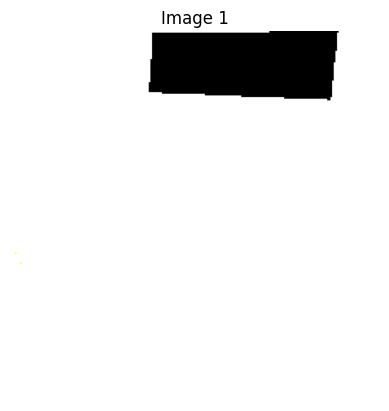

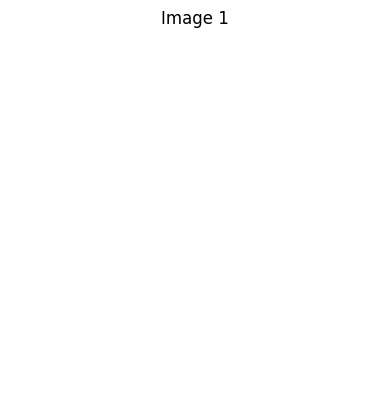

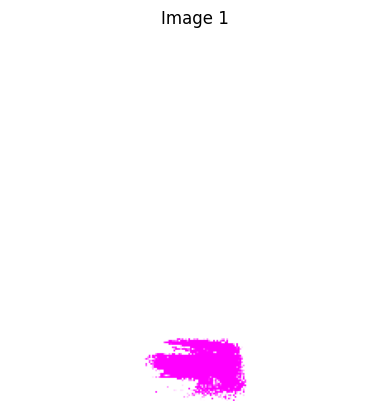

In [ ]:
import matplotlib.pyplot as plt

for x, y in train_ds.take(1):
    img1 = x["img1"]

    for i in range(3):
        plt.imshow(img1[i])
        plt.title("Image 1")
        plt.axis("off")
        plt.show()

In [ ]:
label_counts = y_train.drop(columns=["case_id"]).sum().sort_values()

print(label_counts.head(10))

Stasis Dermatitis                   19.483829
Viral Exanthem                      23.137238
Keratosis pilaris                   23.496647
Molluscum Contagiosum               24.610266
Granuloma annulare                  24.943027
Lichen planus/lichenoid eruption    26.214657
Lichen Simplex Chronicus            27.702152
Pityriasis rosea                    29.420311
Hypersensitivity                    29.839426
Leukocytoclastic Vasculitis         35.141930
dtype: float32


In [ ]:
print((y_train.drop(columns=["case_id"]) > 0).sum(axis=1).describe())

count    1904.000000
mean        1.965861
std         0.900978
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000
dtype: float64


In [ ]:
# Sanity check

for x, y in train_ds.take(1):
    print(x["img1"].shape)

(16, 224, 224, 3)


## **Callbacks**

In [ ]:
import tensorflow as tf

# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Reduce LR on Plateau
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Model Checkpoint
checkpoint_path = "model_checkpoints/custom_siamese.weights.h5"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks = [early_stopping, lr_reducer, model_checkpoint]

## **Custom CNN Siamese Architecture (baseline)**

In [ ]:
# ================================
# Custom Siamese CNN Model
# ================================

import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_SIZE = 224

def build_custom_siamese_model(NUM_CLASSES):

    # ----------------------------
    # 1. Inputs
    # ----------------------------
    img1_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img1")
    img2_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img2")
    img3_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img3")

    # ----------------------------
    # 2. Shared CNN Encoder
    # ----------------------------
    def create_encoder():
        inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

        x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D()(x)

        x = layers.GlobalAveragePooling2D()(x)

        return Model(inputs, x, name="custom_encoder")

    encoder = create_encoder()

    # ----------------------------
    # 3. Feature Extraction
    # ----------------------------
    f1 = encoder(img1_input)
    f2 = encoder(img2_input)
    f3 = encoder(img3_input)

    # ----------------------------
    # 4. Missing Image Handling (FIXED with Lambda)
    # ----------------------------
    def compute_mask(x):
        mask = tf.reduce_sum(x, axis=[1,2,3])
        mask = tf.cast(mask > 0, tf.float32)
        return tf.expand_dims(mask, -1)

    m1 = layers.Lambda(compute_mask, name="mask1")(img1_input)
    m2 = layers.Lambda(compute_mask, name="mask2")(img2_input)
    m3 = layers.Lambda(compute_mask, name="mask3")(img3_input)

    # Apply masking
    f1 = layers.Multiply()([f1, m1])
    f2 = layers.Multiply()([f2, m2])
    f3 = layers.Multiply()([f3, m3])

    # Weighted average
    sum_features = layers.Add()([f1, f2, f3])
    num_valid = layers.Add()([m1, m2, m3])
    num_valid = layers.Lambda(lambda x: x + 1e-6)(num_valid)

    x = layers.Lambda(lambda inputs: inputs[0] / inputs[1])([sum_features, num_valid])

    # ----------------------------
    # 5. Classification Head
    # ----------------------------
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="output")(x)

    # ----------------------------
    # 6. Model
    # ----------------------------
    baseline_model = Model(
        inputs=[img1_input, img2_input, img3_input],
        outputs=outputs,
        name="custom_siamese_model"
    )

    # ----------------------------
    # 7. Compile
    # ----------------------------
    baseline_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.KLDivergence()
    )

    return baseline_model

In [ ]:
# ================================
# Train Custom Siamese Model
# ================================

NUM_CLASSES = y_train.drop(columns=["case_id"]).shape[1]

baseline_model = build_custom_siamese_model(NUM_CLASSES)

baseline_model.summary()

history_custom = baseline_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=callbacks
)

Model: "custom_siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img1 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img2 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img3 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_encoder      │ (None, 128)       │     93,248 │ img1[0][0],       │
│ (Functional)        │                   │            │ img2[0][0],       │
│                     │                   │            │ img3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask1 (Lambda)      │ (None, 1)         │          0 │ img1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask2 (Lambda)      │ (None, 1)         │          0 │ img2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask3 (Lambda)      │ (None, 1)         │          0 │ img3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ custom_encoder[0… │
│                     │                   │            │ mask1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128)       │          0 │ custom_encoder[1… │
│ (Multiply)          │                   │            │ mask2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 128)       │          0 │ custom_encoder[2… │
│ (Multiply)          │                   │            │ mask3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ mask1[0][0],      │
│                     │                   │            │ mask2[0][0],      │
│                     │                   │            │ mask3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ multiply[0][0],   │
│                     │                   │            │ multiply_1[0][0], │
│                     │                   │            │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ add[0][0],        │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0] 

 Total params: 164,191 (641.37 KB)

 Trainable params: 163,679 (639.37 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - loss: 2.8613
Epoch 1: val_loss improved from None to 3.81141, saving model to model_checkpoints/custom_siamese.weights.h5

Epoch 1: finished saving model to model_checkpoints/custom_siamese.weights.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 102s 519ms/step - loss: 2.7329 - val_loss: 3.8114 - learning_rate: 0.0010
Epoch 2/20
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 2.6354
Epoch 2: val_loss did not improve from 3.81141
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - loss: 2.5905 - val_loss: 9.7696 - learning_rate: 0.0010
Epoch 3/20
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 2.5885
Epoch 3: val_loss improved from 3.81141 to 3.00156, saving model to model_checkpoints/custom_siamese.weights.h5

Epoch 3: finished saving model to model_checkpoints/custom_siamese.weights.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 2.5422 - val_loss: 3.0016 - learning_rate: 0.0010
Epoch 4/20
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 2.5

In [ ]:
# ================================
# Testing Custom Siamese Model
# ================================

import numpy as np

y_true = []
y_pred = []

for x, y in test_ds:
    preds = baseline_model.predict(x, verbose=0)

    y_true.append(y.numpy())
    y_pred.append(preds)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

# Top-K Accuracy
print("Top-1 Accuracy:", top_k_accuracy(y_true, y_pred, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_true, y_pred, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_true, y_pred, k=5))

Top-1 Accuracy: 0.36023622047244097
Top-3 Accuracy: 0.610236220472441
Top-5 Accuracy: 0.7204724409448819


## **EfficientNetB0 Siamese feature extractor**

In [ ]:
# ================================
# EfficientNet Siamese (Feature Extractor - Frozen)
# ================================

import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_SIZE = 224

def build_effnet_siamese_feature_extractor(NUM_CLASSES):

    # ----------------------------
    # 1. Inputs
    # ----------------------------
    img1_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img1")
    img2_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img2")
    img3_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img3")

    # ----------------------------
    # 2. Pretrained EfficientNet
    # ----------------------------
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        pooling='avg'
    )

    base_model.trainable = False  #

    # ----------------------------
    # 3. Feature Extraction
    # ----------------------------
    f1 = base_model(img1_input, training=False)
    f2 = base_model(img2_input, training=False)
    f3 = base_model(img3_input, training=False)

    # ----------------------------
    # 4. Missing Image Handling (Lambda)
    # ----------------------------
    def compute_mask(x):
        mask = tf.reduce_sum(x, axis=[1,2,3])
        mask = tf.cast(mask > 0, tf.float32)
        return tf.expand_dims(mask, -1)

    m1 = layers.Lambda(compute_mask)(img1_input)
    m2 = layers.Lambda(compute_mask)(img2_input)
    m3 = layers.Lambda(compute_mask)(img3_input)

    f1 = layers.Multiply()([f1, m1])
    f2 = layers.Multiply()([f2, m2])
    f3 = layers.Multiply()([f3, m3])

    sum_features = layers.Add()([f1, f2, f3])
    num_valid = layers.Add()([m1, m2, m3])
    num_valid = layers.Lambda(lambda x: x + 1e-6)(num_valid)

    x = layers.Lambda(lambda inputs: inputs[0] / inputs[1])([sum_features, num_valid])

    # ----------------------------
    # 5. Classification Head
    # ----------------------------
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="output")(x)

    # ----------------------------
    # 6. Model
    # ----------------------------
    effnet_feature_model = Model(
        inputs=[img1_input, img2_input, img3_input],
        outputs=outputs,
        name="effnet_siamese_feature_extractor"
    )

    # ----------------------------
    # 7. Compile
    # ----------------------------
    effnet_feature_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.KLDivergence()
    )

    return effnet_feature_model

In [ ]:
# ================================
# Train EfficientNet Feature Extractor
# ================================

NUM_CLASSES = y_train.drop(columns=["case_id"]).shape[1]

effnet_feature_model = build_effnet_siamese_feature_extractor(NUM_CLASSES)

effnet_feature_model.summary()

history_effnet_fe = effnet_feature_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    callbacks=callbacks
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "effnet_siamese_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img1 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img2 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img3 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ img1[0][0],       │
│ (Functional)        │                   │            │ img2[0][0],       │
│                     │                   │            │ img3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ img1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ img2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ img3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1280)      │          0 │ efficientnetb0[0… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1280)      │          0 │ efficientnetb0[1… │
│ (Multiply)          │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 1280)      │          0 │ efficientnetb0[2… │
│ (Multiply)          │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0],   │
│                     │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1280)      │          0 │ multiply[0][0],   │
│                     │                   │            │ multiply_1[0][0], │
│                     │                   │            │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1280)      │          0 │ add[0][0],        │
│                     │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]   

 Total params: 4,414,652 (16.84 MB)

 Trainable params: 364,569 (1.39 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - loss: 3.1454
Epoch 1: val_loss improved from None to 2.38045, saving model to model_checkpoints/custom_siamese.weights.h5

Epoch 1: finished saving model to model_checkpoints/custom_siamese.weights.h5
119/119 ━━━━━━━━━━━━━━━━━━━━ 185s 969ms/step - loss: 2.8911 - val_loss: 2.3805 - learning_rate: 5.0000e-04
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - loss: 2.3131
Epoch 2: val_loss improved from 2.38045 to 2.24287, saving model to model_checkpoints/custom_siamese.weights.h5

Epoch 2: finished saving model to model_checkpoints/custom_siamese.weights.h5
119/119 ━━━━━━━━━━━━━━━━━━━━ 84s 711ms/step - loss: 2.3024 - val_loss: 2.2429 - learning_rate: 5.0000e-04
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - loss: 2.1539
Epoch 3: val_loss improved from 2.24287 to 2.18875, saving model to model_checkpoints/custom_siamese.weights.h5

Epoch 3: finished saving model to model_checkpoints/custom_siamese.weights.h5
119/119 ━━

In [ ]:
# ================================
# Testing EfficientNet Feature Extractor
# ================================

import numpy as np

y_true = []
y_pred = []

for x, y in test_ds:
    preds = effnet_feature_model.predict(x, verbose=0)

    y_true.append(y.numpy())
    y_pred.append(preds)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Top-1 Accuracy:", top_k_accuracy(y_true, y_pred, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_true, y_pred, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_true, y_pred, k=5))

Top-1 Accuracy: 0.3888888888888889
Top-3 Accuracy: 0.6872427983539094
Top-5 Accuracy: 0.8065843621399177


## **EfficientNetB0 Siamese Transfer Learning model**

In [ ]:
# ================================
# Fine-Tune EfficientNet (Unfreeze Last 20 Layers)
# ================================

def unfreeze_effnet_last_layers(model, num_layers=30):

    # Get EfficientNet base model inside siamese model
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
            base_model = layer
            break

    if base_model is None:
        raise ValueError("EfficientNet base model not found inside Siamese model")

    print("Found base model:", base_model.name)

    # Freeze all layers first
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers]:
        layer.trainable = False

    for layer in base_model.layers[-num_layers:]:
        layer.trainable = True

    print(f"Unfroze last {num_layers} layers")

    # Recompile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.KLDivergence()
    )

    return model


# Apply fine-tuning setup
effnet_finetuned_model = unfreeze_effnet_last_layers(effnet_feature_model, num_layers=20)

effnet_finetuned_model.summary()

Found base model: efficientnetb0
Unfroze last 20 layers


Model: "effnet_siamese_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img1 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img2 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img3 (InputLayer)   │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ img1[0][0],       │
│ (Functional)        │                   │            │ img2[0][0],       │
│                     │                   │            │ img3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ img1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ img2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1)         │          0 │ img3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (Multiply)          │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 1280)      │          0 │ efficientnetb0[1… │
│ (Multiply)          │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 1280)      │          0 │ efficientnetb0[2… │
│ (Multiply)          │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1)         │          0 │ lambda_2[0][0],   │
│                     │                   │            │ lambda_3[0][0],   │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1280)      │          0 │ multiply_3[0][0], │
│                     │                   │            │ multiply_4[0][0], │
│                     │                   │            │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 1)         │          0 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 1280)      │          0 │ add_2[0][0],      │
│                     │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    327,936 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout_5[0][0] 

 Total params: 4,415,426 (16.84 MB)

 Trainable params: 1,495,119 (5.70 MB)

 Non-trainable params: 2,920,307 (11.14 MB)

In [ ]:
# ================================
# Train Fine-Tuned EfficientNet
# ================================

history_effnet_ft = effnet_finetuned_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 2.3082
Epoch 1: val_loss did not improve from 2.21612
124/124 ━━━━━━━━━━━━━━━━━━━━ 136s 545ms/step - loss: 2.2618 - val_loss: 2.4123 - learning_rate: 5.0000e-04
Epoch 2/10
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.8955
Epoch 2: val_loss did not improve from 2.21612
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 1.9035 - val_loss: 2.4665 - learning_rate: 5.0000e-04
Epoch 3/10
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.6605
Epoch 3: val_loss did not improve from 2.21612
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 1.6199 - val_loss: 2.3179 - learning_rate: 2.5000e-04
Epoch 4/10
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.4840
Epoch 4: val_loss did not improve from 2.21612
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 1.4629 - val_loss: 2.3342 - learning_rate: 2.5000e-04
Epoch 5/10
123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.3268
Epoch 5: val_loss did not improve from 2.21612
124/1

In [ ]:
# ================================
# Testing Fine-Tuned EfficientNet
# ================================

import numpy as np

y_true = []
y_pred = []

for x, y in test_ds:
    preds = effnet_finetuned_model.predict(x, verbose=0)

    y_true.append(y.numpy())
    y_pred.append(preds)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Top-1 Accuracy:", top_k_accuracy(y_true, y_pred, k=1))
print("Top-3 Accuracy:", top_k_accuracy(y_true, y_pred, k=3))
print("Top-5 Accuracy:", top_k_accuracy(y_true, y_pred, k=5))

Top-1 Accuracy: 0.33070866141732286
Top-3 Accuracy: 0.6318897637795275
Top-5 Accuracy: 0.7677165354330708


# ***Phase-5: Model Fusion***
- Best performing metadata learner is `lightgbm` model.
- Best performing image data model is `EfficientNetB0 feature extractor`.
- We will be combining these two models.

## **Late Fusion**
- We will fuse the outputs of the best performing models in both image and metadata using a meta learner.

In [ ]:
# ================================
# Alignment Check
# ================================

# Check 1: All IDs exist in image dataframe
print("Missing in train_image_df:", set(train_ids) - set(train_image_df["case_id"]))
print("Missing in test_image_df:", set(test_ids) - set(test_image_df["case_id"]))

# Check 2: Order consistency (after sorting)
train_image_df_sorted = train_image_df.set_index("case_id").loc[train_ids].reset_index()
test_image_df_sorted  = test_image_df.set_index("case_id").loc[test_ids].reset_index()

print("Train alignment check:", all(train_image_df_sorted["case_id"].values == train_ids))
print("Test alignment check:", all(test_image_df_sorted["case_id"].values == test_ids))

# Check 3: Metadata alignment
print("Metadata train alignment:", all(X_train["case_id"].values == train_ids))
print("Metadata test alignment:", all(X_test["case_id"].values == test_ids))

Missing in train_image_df: set()
Missing in test_image_df: set()
Train alignment check: True
Test alignment check: True
Metadata train alignment: True
Metadata test alignment: True


In [ ]:
# ================================
# Fusion Dataset Builder
# ================================

import tensorflow as tf

def create_fusion_dataset(image_df, ids, batch_size=16):

    # Ensure correct order
    df = image_df.set_index("case_id").loc[ids].reset_index()

    # Extract paths
    img1_paths = df["img1_path"].values
    img2_paths = df["img2_path"].values
    img3_paths = df["img3_path"].values

    dataset = tf.data.Dataset.from_tensor_slices((img1_paths, img2_paths, img3_paths))

    def process(img1, img2, img3):
        # load_image from Phase 4 already handles empty checks and EfficientNet preprocessing
        img1_tensor = load_image(img1)
        img2_tensor = load_image(img2)
        img3_tensor = load_image(img3)

        return {"img1": img1_tensor, "img2": img2_tensor, "img3": img3_tensor}

    dataset = dataset.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


# Create datasets (Aligned to train_ids and test_ids)
fusion_train_images = create_fusion_dataset(train_image_df, train_ids)
fusion_test_images  = create_fusion_dataset(test_image_df, test_ids)

In [ ]:
# ================================
# Feature Extraction for Late Fusion
# ================================

import numpy as np
import tensorflow as tf

# --- 1. Extract Image Features
# Grab the output of the layer just before the final Softmax in our best model
image_feature_layer_name = effnet_feature_model.layers[-2].name
image_feature_extractor = tf.keras.Model(
    inputs=effnet_feature_model.input,
    outputs=effnet_feature_model.get_layer(image_feature_layer_name).output
)

cnn_train_features = image_feature_extractor.predict(fusion_train_images)
cnn_test_features  = image_feature_extractor.predict(fusion_test_images)

# --- 2. Get Tabular Features
tabular_train_features = X_train_baseline
tabular_test_features  = X_test_baseline

# --- 3. Concatenate (Late Fusion)
meta_X_train = np.concatenate([tabular_train_features, cnn_train_features], axis=1)
meta_X_test  = np.concatenate([tabular_test_features, cnn_test_features], axis=1)

print("Fused Train Features Shape:", meta_X_train.shape)
print("Fused Test Features Shape:", meta_X_test.shape)

119/119 ━━━━━━━━━━━━━━━━━━━━ 92s 532ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


NameError: name 'X_train_baseline' is not defined

In [ ]:
# ================================
# Meta Learner Training (Late Fusion Head)
# ================================

import tensorflow as tf
from tensorflow.keras import layers

# --- Labels (KEEP AS SOFT LABELS)
y_train_meta = y_train.set_index("case_id").loc[train_ids]
y_train_meta = y_train_meta.drop(columns=["case_id"], errors="ignore")

NUM_CLASSES = y_train_meta.shape[1]

# --- Build Meta Model (Diamond Architecture)
meta_model = tf.keras.Sequential([
    layers.Input(shape=(meta_X_train.shape[1],)),

    # Crucial: Balances the scales of CNN features vs Tabular features
    layers.BatchNormalization(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

# --- Compile
meta_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.KLDivergence(),
    metrics=['cosine_similarity']
)

# --- Train
history = meta_model.fit(
    meta_X_train,
    y_train_meta.values,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

In [ ]:
# ================================
# Meta Learner Testing
# ================================

from sklearn.metrics import accuracy_score
import numpy as np

# Ground truth alignment
y_test_aligned = y_test.set_index("case_id").loc[test_ids]
y_test_aligned = y_test_aligned.drop(columns=["case_id"], errors="ignore")

# Get hard labels for Top-1 standard accuracy calculation
y_test_labels = np.argmax(y_test_aligned.values, axis=1)

# --- Predictions
final_probs = meta_model.predict(meta_X_test)
final_preds = np.argmax(final_probs, axis=1)

# Metrics
top1 = accuracy_score(y_test_labels, final_preds)

# Using your custom top_k_accuracy function which expects the soft distribution
top3 = top_k_accuracy(y_test_aligned.values, final_probs, k=3)
top5 = top_k_accuracy(y_test_aligned.values, final_probs, k=5)

print(f"Fusion Model Top-1 Accuracy: {top1:.4f}")
print(f"Fusion Model Top-3 Accuracy: {top3:.4f}")
print(f"Fusion Model Top-5 Accuracy: {top5:.4f}")